Домашнее задание №5.

Пайплайн предобработки / FE / генерации данных (если применимо) – 3 баллов

Улучшенная архитектура модели (если применимо) – 4 баллов

Постобработка предсказаний (если применимо) – 3 баллов

Подробный анализ качества модели в разрезе метрик – 5 баллов

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
from pymystem3 import Mystem

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

1. После тестов и бейзлайн решений пробуем увеличить качество модели и усложнить подходы.

Т.к. парсерс выгрузил ещё часть данных с прошлого подхода, увеличим датасет и соберём в юпитере пайплайн предобработки данных, генерации фич.

In [3]:
# загружаем данные и объединяем в единый датафрейм
raw_dataset = pd.read_excel('mortgage_reviews_database_baseline.xlsx')
raw_dataset_2 = pd.read_excel('mortgage_reviews_database_baseline_2.xlsx')

united_df = pd.concat([raw_dataset, raw_dataset_2], ignore_index=True)

In [4]:
# увеличили датасет с 19640 до 44829 строк
united_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44829 entries, 0 to 44828
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          44829 non-null  int64  
 1   Заголовок                   44829 non-null  object 
 2   Пользователь (API)          44825 non-null  object 
 3   Оценка                      41299 non-null  float64
 4   Дата создания (API)         44829 non-null  object 
 5   Количество комментариев     44829 non-null  int64  
 6   Учитывается в рейтинге      40735 non-null  object 
 7   Статус отзыва               44829 non-null  object 
 8   Текст отзыва (API)          44828 non-null  object 
 9   Название банка              44829 non-null  object 
 10  ID банка                    44829 non-null  int64  
 11  Регион банка                44744 non-null  object 
 12  Ответ банка (API)           43326 non-null  object 
 13  ID сотрудника               433

In [5]:
# 1 часть пайплайна - на pandas (до перехода на БД в MVP в задаче 6 урока)

united_df['Дата создания (API)'] = pd.to_datetime(united_df['Дата создания (API)'])
united_df['Дата отзыва (страница)'] = pd.to_datetime(united_df['Дата отзыва (страница)'])

improved_baseline_dataset = united_df[[
    'Дата создания (API)',
    'Заголовок',
    'Текст отзыва (API)',
    'Город пользователя',

    'ID банка',
    'Название банка',
    'ID сотрудника',
    'Ответ банка (API)',
    'Количество комментариев',

    'Учитывается в рейтинге',
    'Статус отзыва',

    'Рейтинг (страница)', # оценка пользователя
    'Прозрачные условия',
    'Вежливые сотрудники',
    'Доступность и поддержка',
    'Удобство приложения, сайта',
]]

# Собрали датасет, начинаем последовательную фильтрацию и отчистку
improved_baseline_dataset = improved_baseline_dataset[improved_baseline_dataset['Учитывается в рейтинге'] == 'Да']
improved_baseline_dataset = improved_baseline_dataset[improved_baseline_dataset['Статус отзыва'] == 'Зачтено']
improved_baseline_dataset['ID сотрудника'] = improved_baseline_dataset['ID сотрудника'].fillna(0)
improved_baseline_dataset['ID сотрудника'] = improved_baseline_dataset['ID сотрудника'].astype(int)
improved_baseline_dataset['Ответ банка (API)'] = improved_baseline_dataset['Ответ банка (API)'].fillna('Нет ответа')

# Работаем с пропусками в столбцах с оценкой
improved_baseline_dataset['Прозрачные условия'] = improved_baseline_dataset.groupby('Название банка')['Прозрачные условия'].transform(lambda x: x.fillna(x.mean()).round(2))
improved_baseline_dataset['Вежливые сотрудники'] = improved_baseline_dataset.groupby('Название банка')['Вежливые сотрудники'].transform(lambda x: x.fillna(x.mean()).round(2))
improved_baseline_dataset['Доступность и поддержка'] = improved_baseline_dataset.groupby('Название банка')['Доступность и поддержка'].transform(lambda x: x.fillna(x.mean()).round(2))
improved_baseline_dataset['Удобство приложения, сайта'] = improved_baseline_dataset.groupby('Название банка')['Удобство приложения, сайта'].transform(lambda x: x.fillna(x.mean()).round(2))

# удаляем оставшиеся пропуски, они не критичны для нас на данном этапе
improved_baseline_dataset = improved_baseline_dataset.dropna()

# делаем резервное сохранение отчищенного датасета
improved_baseline_dataset.to_csv('D:/pars/improved_baseline_dataset.csv')

C:\Users\Игорь\AppData\Local\Temp\ipykernel_21116\1846653532.py:4: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  united_df['Дата отзыва (страница)'] = pd.to_datetime(united_df['Дата отзыва (страница)'])


In [6]:
# 2 часть пайплайна с генерацией признаков
nltk.download('stopwords')

# Инициализируем лемматизатор - будет использован в более сложных моделях
mystem = Mystem()

# Русские стоп-слова
russian_stopwords = stopwords.words('russian')
# Добавим дополнительные стоп-слова
additional_stopwords = ['это', 'как', 'так', 'и', 'в', 'над', 'к', 'до', 'не', 'на', 'но', 'за', 'то', 'с',
                       'ли', 'а', 'во', 'от', 'со', 'для', 'о', 'же', 'ну', 'вы', 'бы', 'что', 'кто',
                       'он', 'она', 'год', 'весь', 'свой', 'банк', 'кредит', 'карта', 'счёт', 'отзыв']
russian_stopwords.extend(additional_stopwords)



def clean_russian_text(text):
    """
    Очистка и подготовка русского текста
    """
    if pd.isna(text):
        return ""

    # Приводим к строке
    text = str(text)
    # Приводим к нижнему регистру
    text = text.lower()
    # Удаляем HTML-теги
    text = re.sub(r'<[^>]+>', '', text)
    # Удаляем URL
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Удаляем email
    text = re.sub(r'\S+@\S+', '', text)
    # Удаляем числа
    text = re.sub(r'\d+', '', text)
    # Удаляем пунктуацию и специальные символы
    text = re.sub(r'[^\w\s]', ' ', text)
    # Удаляем лишние пробелы
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def lemmatize_text(text):
    """
    Лемматизация русского текста
    """
    if not text:
        return ""

    # Лемматизируем
    lemmas = mystem.lemmatize(text)
    # Объединяем обратно
    lemmatized_text = ''.join(lemmas).strip()
    # Удаляем стоп-слова
    words = lemmatized_text.split()
    filtered_words = [word for word in words if word not in russian_stopwords and len(word) > 2]

    return ' '.join(filtered_words)

def vectorize_with_tfidf(texts, max_features=5000, ngram_range=(1, 2)):
    """
    Векторизация текстов с помощью TF-IDF
    Returns:
    --------
    tuple: (векторизованные данные, векторный преобразователь)
    """
    # Инициализируем TF-IDF векторизатор
    tfidf = TfidfVectorizer(
        max_features=max_features,
        ngram_range=ngram_range,
        min_df=2,  # слово должно встречаться минимум в 2 документах
        max_df=0.8,  # слово должно встречаться максимум в 80% документов
        stop_words=russian_stopwords
    )

    # Преобразуем тексты
    vectors = tfidf.fit_transform(texts)

    return vectors, tfidf

# # Основной пайплайн - оставляем на эксперименты с улучшением качества работы модели на домашнем задании 5-го урока.
def process_dataframe(df):
    """
    пайплайн обработки и векторизации текстов
    """
    # 1. Создаем копию датафрейма чтобы не изменять оригинал
    df_processed = df.copy()

    print("Начало обработки текстов...")

    # 2. Очищаем тексты отзывов
    print("Шаг 1: Очистка текстов отзывов...")
    df_processed['Текст отзыва отчищенный'] = df_processed['Текст отзыва (API)'].apply(clean_russian_text)

    # 3. Лемматизируем тексты отзывов
    print("Шаг 2: Лемматизация текстов отзывов...")
    df_processed['Текст отзыва отчищенный'] = df_processed['Текст отзыва отчищенный'].apply(lemmatize_text)

    # 4. Очищаем заголовки (более простая очистка)
    print("Шаг 3: Очистка заголовков...")
    df_processed['Заголовок_очищенный'] = df_processed['Заголовок'].apply(
        lambda x: clean_russian_text(x) if pd.notna(x) else ""
    )

    # 5. Векторизуем заголовки
    print("Шаг 4: Векторизация заголовков...")
    title_texts = df_processed['Заголовок_очищенный'].fillna('').tolist()
    title_vectors, title_tfidf = vectorize_with_tfidf(
        title_texts,
        max_features=2000,  # Меньше фич для заголовков
        ngram_range=(1, 2)
    )

    # 6. Векторизуем тексты отзывов
    print("Шаг 5: Векторизация текстов отзывов...")
    review_texts = df_processed['Текст отзыва отчищенный'].fillna('').tolist()
    review_vectors, review_tfidf = vectorize_with_tfidf(
        review_texts,
        max_features=10000,  # Больше фич для полных текстов
        ngram_range=(1, 3)   # Более длинные n-граммы
    )

    # 7. Преобразуем векторы в списки для сохранения в датафрейме
    print("Шаг 6: Сохранение векторов...")

    # Для заголовков сохраняем только наиболее важные признаки
    title_vectors_dense = title_vectors.toarray()
    # Сохраняем как список
    df_processed['Заголовок_TFIDF'] = list(title_vectors_dense)

    # Для текстов отзывов
    review_vectors_dense = review_vectors.toarray()
    df_processed['Текст отзыва отчищенный_TFIDF'] = list(review_vectors_dense)

    print(f"Обработка завершена!")
    print(f"Обработано {len(df_processed)} строк")
    print(f"Размерность векторов заголовков: {title_vectors.shape[1]}")
    print(f"Размерность векторов отзывов: {review_vectors.shape[1]}")

    # Возвращаем обработанный датафрейм и векторизаторы
    return df_processed, title_tfidf, review_tfidf


# Упрощенный вариант (без лемматизации) - использовали в 4 уроке
def process_dataframe_simple(df):
    """
    Упрощенный вариант для быстрой обработки
    """
    df_processed = df.copy()

    # Простая очистка текста
    def simple_clean(text):
        if pd.isna(text):
            return ""
        text = str(text).lower()
        text = re.sub(r'[^\w\s]', ' ', text)
        text = re.sub(r'\d+', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    # Очистка
    df_processed['Текст отзыва отчищенный'] = df_processed['Текст отзыва (API)'].apply(simple_clean)
    df_processed['Заголовок_очищенный'] = df_processed['Заголовок'].apply(simple_clean)

    # TF-IDF векторизация
    tfidf_title = TfidfVectorizer(max_features=1000, stop_words=russian_stopwords)
    tfidf_review = TfidfVectorizer(max_features=5000, stop_words=russian_stopwords)

    title_vectors = tfidf_title.fit_transform(df_processed['Заголовок_очищенный'])
    review_vectors = tfidf_review.fit_transform(df_processed['Текст отзыва отчищенный'])

    # Сохраняем векторы
    df_processed['Заголовок_TFIDF'] = [title_vectors[i].toarray().flatten() for i in range(len(df_processed))]
    df_processed['Текст отзыва отчищенный_TFIDF'] = [review_vectors[i].toarray().flatten() for i in range(len(df_processed))]

    return df_processed, tfidf_title, tfidf_review


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Игорь\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
# Пример с тестовыми данными
test_data = {
    'Заголовок': ['Отличный банк!', 'Ужасное обслуживание', 'Нормальный сервис'],
    'Текст отзыва (API)': [
        'Банк очень хороший, быстро отвечают на вопросы. Рекомендую всем!',
        'Ужасный сервис, долго ждал ответа от поддержки. Не рекомендую.',
        'Всё нормально, но есть мелкие недочёты в работе приложения.'
    ]
}

df_test = pd.DataFrame(test_data)

print("Тест обработки данных:")
print("Исходные данные:")
print(df_test)

# Обработка
df_processed, title_tfidf, review_tfidf = process_dataframe_simple(df_test)

print("\nОбработанные данные:")
print(df_processed[['Заголовок', 'Текст отзыва отчищенный']])

print(f"\nРазмерность TF-IDF векторов заголовков: {len(df_processed['Заголовок_TFIDF'].iloc[0])}")
print(f"Размерность TF-IDF векторов отзывов: {len(df_processed['Текст отзыва отчищенный_TFIDF'].iloc[0])}")

# Пример доступа к TF-IDF признакам
print(f"\nПример TF-IDF признаков для заголовков (первые 10):")
feature_names = title_tfidf.get_feature_names_out()
print(feature_names[:10])

Тест обработки данных:
Исходные данные:
              Заголовок                                 Текст отзыва (API)
0        Отличный банк!  Банк очень хороший, быстро отвечают на вопросы...
1  Ужасное обслуживание  Ужасный сервис, долго ждал ответа от поддержки...
2     Нормальный сервис  Всё нормально, но есть мелкие недочёты в работ...

Обработанные данные:
              Заголовок                            Текст отзыва отчищенный
0        Отличный банк!  банк очень хороший быстро отвечают на вопросы ...
1  Ужасное обслуживание  ужасный сервис долго ждал ответа от поддержки ...
2     Нормальный сервис  всё нормально но есть мелкие недочёты в работе...

Размерность TF-IDF векторов заголовков: 5
Размерность TF-IDF векторов отзывов: 19

Пример TF-IDF признаков для заголовков (первые 10):
['нормальный' 'обслуживание' 'отличный' 'сервис' 'ужасное']


In [8]:
# проверка
required_columns = ['Заголовок', 'Текст отзыва (API)']

if all(col in improved_baseline_dataset.columns for col in required_columns):
    print(f"Найдены все необходимые столбцы в baseline_dataset")
    print(f"Размер датафрейма: {improved_baseline_dataset.shape}")

    # обработка
    improved_baseline_dataset, title_tfidf, review_tfidf = process_dataframe_simple(improved_baseline_dataset)

    # результат
    print(f"\nРезультат обработки:")
    print(f"Исходный размер: {improved_baseline_dataset.shape}")
    print(f"Обработанный размер: {improved_baseline_dataset.shape}")
    print(f"\nНовые столбцы:")
    for col in improved_baseline_dataset.columns:
        if col not in improved_baseline_dataset.columns:
            print(f"  - {col}")

else:
    missing = [col for col in required_columns if col not in improved_baseline_dataset.columns]
    print(f"ОШИБКА: Не найдены столбцы: {missing}")
    print(f"Доступные столбцы: {list(improved_baseline_dataset.columns)}")

Найдены все необходимые столбцы в baseline_dataset
Размер датафрейма: (18077, 16)

Результат обработки:
Исходный размер: (18077, 20)
Обработанный размер: (18077, 20)

Новые столбцы:


In [9]:
improved_baseline_dataset

,Дата создания (API),Заголовок,Текст отзыва (API),Город пользователя,ID банка,Название банка,ID сотрудника,Ответ банка (API),Количество комментариев,Учитывается в рейтинге,Статус отзыва,Рейтинг (страница),Прозрачные условия,Вежливые сотрудники,Доступность и поддержка,"Удобство приложения, сайта",Текст отзыва отчищенный,Заголовок_очищенный,Заголовок_TFIDF,Текст отзыва отчищенный_TFIDF
92,2025-11-14 07:25:46,Открытие текущего счета,14.11.2025 пришли в банк Дом РФ-одобрили ипоте...,Тюмень (Тюменская область),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим за ...,1,Да,Зачтено,5.0,3.00,3.00,3.00,3.00,пришли в банк дом рф одобрили ипотеку взяли та...,открытие текущего счета,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
124,2025-11-13 13:07:32,Идентификация,13.11.25 обратилась в офис банка в городк Тюме...,Тюмень (Тюменская область),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим вас...,2,Да,Зачтено,5.0,3.00,3.00,3.00,3.00,обратилась в офис банка в городк тюмени ипотек...,идентификация,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
125,2025-11-13 12:59:38,Консультация,Обратился в отделение банка 13 ноября этого го...,Пермь (Пермский край),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим вас...,2,Да,Зачтено,5.0,3.00,3.00,3.00,3.00,обратился в отделение банка ноября этого года ...,консультация,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
130,2025-11-13 11:49:12,Справка,Сегодня в 16:30 пришла в банк Дом Рф в городе ...,Иркутск (Иркутская область),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим за ...,1,Да,Зачтено,5.0,3.00,3.00,3.00,3.00,сегодня в пришла в банк дом рф в городе иркутс...,справка,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
132,2025-11-13 11:32:24,Оформление нового счета,13.11.2025 года посетила офис Банка Дом Рф в г...,Ижевск (Удмуртская Республика),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим вас...,1,Да,Зачтено,5.0,3.00,3.00,3.00,3.00,года посетила офис банка дом рф в городе ижевс...,оформление нового счета,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44819,2020-03-16 21:56:35,Менеджер по ипотеке,Здравствуйте. _x000D_\n6 марта пришло смс одоб...,Балаково (Саратовская область),690,Банк «Открытие»,690,"Добрый день._x000D_\n_x000D_\nИзвините, пожалу...",11,Да,Зачтено,2.0,1.32,1.72,1.10,1.42,здравствуйте _xd_ марта пришло смс одобрение и...,менеджер по ипотеке,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.053574710012306556, 0.0, 0.0, 0.0, 0.0, 0.0..."
44820,2020-03-16 21:26:28,Нет никакой Сельской Ипотеки! Обман!,"Если бы я знал, что все так будет, то не трати...",Санкт-Петербург,4725,Россельхозбанк,4725,Уважаемый Клиент!_x000D_\nБлагодарим Вас за вн...,4,Да,Зачтено,1.0,2.41,2.57,2.33,2.42,если бы я знал что все так будет то не тратил ...,нет никакой сельской ипотеки обман,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.20807984535010723, 0.0, 0.0, 0.0, 0.0, 0.0,..."
44821,2020-03-16 21:21:30,Рефинансирование ипотеки,В начале марта 2020 г. задумал рефинансировать...,Нижний Новгород (Нижегородская область),2237,Банк ДОМ.РФ,2237,Уважаемый Клиент!_x000D_\n_x000D_\nСпасибо за ...,4,Да,Зачтено,2.0,2.63,2.72,2.55,2.62,в начале марта г задумал рефинансировать свою ...,рефинансирование ипотеки,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.2160220691469796, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
44822,2020-03-16 20:55:48,Как я оформил ипотеку в альфа банке,"Решил написать отзыв, о покупке в город в лесу...",Москва,325,Альфа-Банк,325,"Уважаемый Клиент,_x000D_\n_x000D_\nблагодарим ...",1,Да,Зачтено,5.0,2.31,2.51,2.31,2.43,решил написать отзыв о покупке в город 

In [10]:
def calculate_text_length_metrics(text):
    """
    Вычисляет несколько метрик длины текста
    """
    if pd.isna(text) or text == "":
        return {
            'символов': 0,
            'слов': 0,
            'уникальных_слов': 0,
            'предложений': 0
        }

    text_str = str(text)

    # Количество символов
    chars = len(text_str)

    # Количество слов
    words = text_str.split()
    word_count = len(words)

    # Количество уникальных слов
    unique_words = len(set(words))

    return {
        'символов': chars,
        'слов': word_count,
        'уникальных_слов': unique_words,
    }

# Применяем функцию
metrics = improved_baseline_dataset['Текст отзыва отчищенный'].apply(calculate_text_length_metrics)

# Создаем отдельные столбцы
improved_baseline_dataset['текст_символов'] = metrics.apply(lambda x: x['символов'])
improved_baseline_dataset['текст_слов'] = metrics.apply(lambda x: x['слов'])
improved_baseline_dataset['текст_уникальных_слов'] = metrics.apply(lambda x: x['уникальных_слов'])

print("Добавлены столбцы:")
print("- 'текст_символов'")
print("- 'текст_слов'")
print("- 'текст_уникальных_слов'")

Добавлены столбцы:
- 'текст_символов'
- 'текст_слов'
- 'текст_уникальных_слов'


In [11]:
def count_sentences(text):
    """
    Подсчет предложений в тексте
    """
    if pd.isna(text) or text == "":
        return 0

    text = str(text)

    # Удаляем сокращения, которые могут быть приняты за конец предложения
    text = re.sub(r'т\.д\.|т\.п\.|др\.|пр\.|г\.|гг\.|см\.|рис\.|стр\.', '', text)

    # Разбиваем по точкам, восклицательным и вопросительным знакам
    sentences = re.split(r'[.!?]+', text)

    # Фильтруем пустые строки
    sentences = [s.strip() for s in sentences if s.strip()]

    return len(sentences)

# Применяем функцию к оригинальному столбцу
print("Подсчет предложений в столбце 'Текст отзыва (API)'...")
improved_baseline_dataset['количество_предложений'] = improved_baseline_dataset['Текст отзыва (API)'].apply(count_sentences)

print(f"✅ Добавлен столбец 'количество_предложений'")

# Показываем статистику
print("\n📊 Статистика по количеству предложений:")
print(f"   Всего отзывов: {len(improved_baseline_dataset)}")
print(f"   Среднее количество предложений: {improved_baseline_dataset['количество_предложений'].mean():.2f}")
print(f"   Медианное количество: {improved_baseline_dataset['количество_предложений'].median():.1f}")
print(f"   Минимум: {improved_baseline_dataset['количество_предложений'].min()}")
print(f"   Максимум: {improved_baseline_dataset['количество_предложений'].max()}")

Подсчет предложений в столбце 'Текст отзыва (API)'...
✅ Добавлен столбец 'количество_предложений'

📊 Статистика по количеству предложений:
   Всего отзывов: 18077
   Среднее количество предложений: 17.17
   Медианное количество: 14.0
   Минимум: 1
   Максимум: 155


In [12]:
# Создание целевой переменной с 3 классами
def create_sentiment_label(rating):
    if pd.isna(rating):
        return np.nan
    try:
        rating_num = float(rating)
        if rating_num >= 4:
            return '2'
        elif rating_num == 3:
            return '1'
        else:
            return '0'
    except:
        return np.nan

rating_column = 'Рейтинг (страница)'
improved_baseline_dataset['тональность'] = improved_baseline_dataset[rating_column].apply(create_sentiment_label)

# Удаляем пропуски
improved_baseline_dataset = improved_baseline_dataset.dropna(subset=['тональность'])

# Статистика
print("Распределение классов:")
print(improved_baseline_dataset['тональность'].value_counts())

Распределение классов:
тональность
0    14118
2     3421
1      538
Name: count, dtype: int64


In [13]:
# увеличили выборку для обучения с 5671 до 18077
# TF-IDF векторы
X_title = np.vstack(improved_baseline_dataset['Заголовок_TFIDF'].values)
X_review = np.vstack(improved_baseline_dataset['Текст отзыва отчищенный_TFIDF'].values)
X_tfidf = np.hstack([X_title, X_review])

# Количественные признаки
quant_features = []
if 'длина_отзыва' in improved_baseline_dataset.columns:
    quant_features.append('длина_отзыва')
if 'слов_в_отзыве' in improved_baseline_dataset.columns:
    quant_features.append('слов_в_отзыве')
if 'предложений_в_тексте' in improved_baseline_dataset.columns:
    quant_features.append('предложений_в_тексте')

X_quant = improved_baseline_dataset[quant_features].values if quant_features else np.array([])

# Объединение признаков
if X_quant.size > 0:
    X_combined = np.hstack([X_tfidf, X_quant])
else:
    X_combined = X_tfidf

# Целевая переменная (числовая)
y = improved_baseline_dataset['тональность'].values.astype(int)

print(f"Признаков: {X_combined.shape[1]}, Объектов: {X_combined.shape[0]}")
print(f"Целевая переменная: {y[:10]}...")

Признаков: 6000, Объектов: 18077
Целевая переменная: [2 2 2 2 2 2 0 2 2 2]...


Закончили с пайплайном, переходим к проверки модели предыдущего урока и улучшению показателей

In [19]:
# проверяем результат на старой модели
import joblib

# Подготовка данных
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

# Загрузка модели
model = joblib.load('D:/pars/best_model_logistic_regression.pkl')  # или best_model_logistic_regression.pkl

def predict_model(model, X_train, X_test, y_train, y_test, model_name=""):
    """Оценка модели с ключевыми метриками"""
    # Предсказания
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

    # Основные метрики
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision_macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
        'precision_weighted': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall_weighted': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1_weighted': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    }

    # ROC-AUC
    if y_pred_proba is not None:
        try:
            metrics['roc_auc_ovr'] = roc_auc_score(
                y_test, y_pred_proba, multi_class='ovr', average='macro'
            )
            metrics['roc_auc_ovo'] = roc_auc_score(
                y_test, y_pred_proba, multi_class='ovo', average='macro'
            )
        except:
            metrics['roc_auc_ovr'] = None
            metrics['roc_auc_ovo'] = None

    # Вывод результатов
    print(f"\n{'='*50}")
    print(f"{model_name}")
    print(f"{'='*50}")

    print("\nОсновные метрики:")
    print(f"  Accuracy:           {metrics['accuracy']:.4f}")
    print(f"  F1-weighted:        {metrics['f1_weighted']:.4f}")
    print(f"  F1-macro:           {metrics['f1_macro']:.4f}")
    print(f"  Precision-weighted: {metrics['precision_weighted']:.4f}")
    print(f"  Recall-weighted:    {metrics['recall_weighted']:.4f}")

    if metrics.get('roc_auc_ovr'):
        print(f"  ROC-AUC (OVR):      {metrics['roc_auc_ovr']:.4f}")

    # Детальный отчет
    print(f"\nПо классам:")
    print(classification_report(
        y_test, y_pred,
        target_names=['негатив (0)', 'нейтрал (1)', 'позитив (2)'],
        zero_division=0
    ))

    return model, metrics, y_pred, y_pred_proba

logreg_results = predict_model(model, X_train, X_test, y_train, y_test, "LOGISTIC REGRESSION")


LOGISTIC REGRESSION

Основные метрики:
  Accuracy:           0.7810
  F1-weighted:        0.7491
  F1-macro:           0.4146
  Precision-weighted: 0.7351
  Recall-weighted:    0.7810
  ROC-AUC (OVR):      0.6694

По классам:
              precision    recall  f1-score   support

 негатив (0)       0.82      0.93      0.87      2824
 нейтрал (1)       0.05      0.01      0.02       108
 позитив (2)       0.49      0.28      0.36       684

    accuracy                           0.78      3616
   macro avg       0.46      0.41      0.41      3616
weighted avg       0.74      0.78      0.75      3616



Итого, мы видим, что лучшая модель с 4 урока без оптимизации параметров сильно теряет в качестве
Было F1-weighted: 0.9324 vs стало F1-weighted: 0.7491

Ещё раз взглянем на наш датасет и определим, что можем улучшить.
Наш основной подход - основан на статистическом методе TF-IDF и количественных показателей текстов отзывов. Вероятно, используя методы, учитывающие семантическую часть текста - мы можем получить лучшее качество моделей.

In [24]:
improved_baseline_dataset

,Дата создания (API),Заголовок,Текст отзыва (API),Город пользователя,ID банка,Название банка,ID сотрудника,Ответ банка (API),Количество комментариев,Учитывается в рейтинге,...,"Удобство приложения, сайта",Текст отзыва отчищенный,Заголовок_очищенный,Заголовок_TFIDF,Текст отзыва отчищенный_TFIDF,текст_символов,текст_слов,текст_уникальных_слов,количество_предложений,тональность
92,2025-11-14 07:25:46,Открытие текущего счета,14.11.2025 пришли в банк Дом РФ-одобрили ипоте...,Тюмень (Тюменская область),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим за ...,1,Да,...,3.00,пришли в банк дом рф одобрили ипотеку взяли та...,открытие текущего счета,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",336,49,45,3,2
124,2025-11-13 13:07:32,Идентификация,13.11.25 обратилась в офис банка в городк Тюме...,Тюмень (Тюменская область),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим вас...,2,Да,...,3.00,обратилась в офис банка в городк тюмени ипотек...,идентификация,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",394,60,49,3,2
125,2025-11-13 12:59:38,Консультация,Обратился в отделение банка 13 ноября этого го...,Пермь (Пермский край),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим вас...,2,Да,...,3.00,обратился в отделение банка ноября этого года ...,консультация,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",445,65,51,8,2
130,2025-11-13 11:49:12,Справка,Сегодня в 16:30 пришла в банк Дом Рф в городе ...,Иркутск (Иркутская область),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим за ...,1,Да,...,3.00,сегодня в пришла в банк дом рф в городе иркутс...,справка,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",520,85,71,9,2
132,2025-11-13 11:32:24,Оформление нового счета,13.11.2025 года посетила офис Банка Дом Рф в г...,Ижевск (Удмуртская Республика),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим вас...,1,Да,...,3.00,года посетила офис банка дом рф в городе ижевс...,оформление нового счета,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",348,50,43,6,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44819,2020-03-16 21:56:35,Менеджер по ипотеке,Здравствуйте. _x000D_\n6 марта пришло смс одоб...,Балаково (Саратовская область),690,Банк «Открытие»,690,"Добрый день._x000D_\n_x000D_\nИзвините, пожалу...",11,Да,...,1.42,здравствуйте _xd_ марта пришло смс одобрение и...,менеджер по ипотеке,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.053574710012306556, 0.0, 0.0, 0.0, 0.0, 0.0...",334,52,47,7,0
44820,2020-03-16 21:26:28,Нет никакой Сельской Ипотеки! Обман!,"Если бы я знал, что все так будет, то не трати...",Санкт-Петербург,4725,Россельхозбанк,4725,Уважаемый Клиент!_x000D_\nБлагодарим Вас за вн...,4,Да,...,2.42,если бы я знал что все так будет то не тратил ...,нет никакой сельской ипотеки обман,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.20807984535010723, 0.0, 0.0, 0.0, 0.0, 0.0,...",1318,214,157,21,0
44821,2020-03-16 21:21:30,Рефинансирование ипотеки,В начале марта 2020 г. задумал рефинансировать...,Нижний Новгород (Нижегородская область),2237,Банк ДОМ.РФ,2237,Уважаемый Клиент!_x000D_\n_x000D_\nСпасибо за ...,4,Да,...,2.62,в начале марта г задумал рефинансировать свою ...,рефинансирование ипотеки,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.2160220691469796, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1109,173,116,12,0
44822,2020-03-16 20:55:48,Как я оформил ипотеку в альфа банке,"Решил написать отзыв, о покупке в город в лесу...",Москва,325,Альфа-Банк,325,"Уважаемый Клиент,_x000D_\n_x000D_\nблагодарим ...",1,Да,...,2.43,решил написать отзыв о покупке в город в лесу ...,как я оформил ипотеку в альфа банке,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0

In [ ]:
# пробуем варианты векторизации русского текста с сохранением смысловой части

In [20]:
from transformers import AutoTokenizer, AutoModel
import torch


# Mean Pooling - Take attention mask into account for correct averaging
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0] #First element of model_output contains all token embeddings
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)


# Sentences we want sentence embeddings for
sentences = ['This is an example sentence', 'Each sentence is converted']

# Load model from HuggingFace Hub
tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')
model = AutoModel.from_pretrained('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

# Tokenize sentences
encoded_input = tokenizer(sentences, padding=True, truncation=True, return_tensors='pt')

# Compute token embeddings
with torch.no_grad():
    model_output = model(**encoded_input)

# Perform pooling. In this case, max pooling.
sentence_embeddings = mean_pooling(model_output, encoded_input['attention_mask'])

print("Sentence embeddings:")
print(sentence_embeddings)

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

D:\pars\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Игорь\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

Sentence embeddings:
tensor([[ 0.1885,  0.1743,  0.0545,  0.2905,  0.1677, -0.0472,  0.6456,  0.1598,
          0.2269, -0.0309,  0.2559, -0.0526, -0.2261, -0.0571,  0.1304,  0.1250,
          0.3175,  0.1944, -0.5863, -0.0126,  0.6099,  0.1643,  0.0333, -0.2738,
         -0.2898, -0.2112, -0.0226, -0.1704,  0.1616,  0.0608, -0.2416,  0.1858,
          0.4274,  0.1930, -0.0723,  0.1661,  0.1044,  0.2048,  0.2112,  0.1997,
         -0.0941, -0.1738,  0.0643,  0.2803, -0.2953,  0.0621,  0.1043, -0.0236,
          0.1291, -0.1262, -0.1790,  0.0370, -0.6125,  0.0503,  0.1773,  0.2249,
          0.1739, -0.0384, -0.2129,  0.2585, -0.1210,  0.3097, -0.4197,  0.0091,
          0.1419, -0.3056,  0.1762, -0.0709, -0.6203,  0.6771,  0.0172,  0.1841,
         -0.1679,  0.2045, -0.1477, -0.0618,  0.6302,  0.1112,  0.0515,  0.1593,
         -0.0537,  0.0535,  0.1414,  0.1124, -0.4841, -0.1699, -0.0532,  0.2765,
          0.1178, -0.3491, -0.5138, -0.3284,  0.5424, -0.0533,  0.2292, -0.0128,
       

In [22]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('cointegrated/rubert-tiny2')
sentences = ["привет мир", "hello world", "здравствуй вселенная"]
embeddings = model.encode(sentences)
print(embeddings)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

D:\pars\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Игорь\.cache\huggingface\hub\models--cointegrated--rubert-tiny2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

[[ 1.93479583e-02 -2.03979984e-02 -8.45529046e-03 -6.85828850e-02
  -1.67201052e-03  3.86167057e-02 -1.27368346e-02 -3.14126797e-02
  -7.30952770e-02 -4.57527339e-02  1.95689201e-02  7.20972866e-02
   8.39340985e-02  4.11881767e-02  3.29586156e-02 -6.46812022e-02
   1.07747138e-01  1.74315162e-02 -4.82149469e-03  4.41244841e-02
   4.88842502e-02  2.57911012e-02  4.95995507e-02 -7.43956678e-03
   6.54861331e-02  1.71001665e-02 -7.56175071e-02  7.08267605e-03
  -4.15338017e-02  5.64554483e-02 -4.71330881e-02 -5.52772693e-02
   1.06138386e-01 -2.34869197e-02 -1.73601657e-02  1.06622368e-01
  -3.67118306e-02 -3.43236662e-02 -1.06261611e-01  1.56027386e-02
  -9.50848460e-02  1.52671173e-01  1.28692538e-01 -4.05505970e-02
   9.49789677e-03  1.58098564e-02  5.39585240e-02 -2.82900482e-02
   2.27004439e-02 -5.47641627e-02  4.87861820e-02 -4.12375033e-02
   7.44176097e-03 -4.16501351e-02 -4.70889285e-02  5.22873402e-02
   1.19798936e-01  2.35627629e-02 -5.26659451e-02 -5.11540798e-03
   3.04333

In [25]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
import torch
from tqdm import tqdm
import time

class DualModelVectorizer:
    """
    Класс для векторизации текстов двумя моделями:
    1. SBERT (paraphrase-multilingual-MiniLM-L12-v2)
    2. RuBERT-Tiny2 (cointegrated/rubert-tiny2)
    """

    def __init__(self):
        """Инициализация обеих моделей"""
        print("🔄 Загрузка моделей...")

        # Модель 1: SBERT (международная, 384 измерения)
        print("1. Загрузка SBERT (paraphrase-multilingual-MiniLM-L12-v2)...")
        self.sbert_model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')
        self.sbert_dim = self.sbert_model.get_sentence_embedding_dimension()

        # Модель 2: RuBERT-Tiny2 (русскоязычная, 312 измерений)
        print("2. Загрузка RuBERT-Tiny2 (cointegrated/rubert-tiny2)...")
        self.rubert_model = SentenceTransformer('cointegrated/rubert-tiny2')
        self.rubert_dim = self.rubert_model.get_sentence_embedding_dimension()

        print(f"✅ Модели загружены:")
        print(f"   - SBERT: {self.sbert_dim} измерений")
        print(f"   - RuBERT-Tiny2: {self.rubert_dim} измерений")

    def vectorize_batch(self, texts, batch_size=32, model_type='both'):
        """
        Векторизация пакета текстов

        Parameters:
        -----------
        texts : list
            Список текстов для векторизации
        batch_size : int
            Размер пакета для обработки
        model_type : str
            'sbert' - только SBERT
            'rubert' - только RuBERT-Tiny2
            'both' - обе модели (по умолчанию)

        Returns:
        --------
        dict: Словарь с векторами от каждой модели
        """
        if not texts:
            return {}

        print(f"📊 Векторизация {len(texts)} текстов...")

        results = {}

        # Векторизация SBERT
        if model_type in ['sbert', 'both']:
            print(f"\n🔹 SBERT векторизация...")
            start_time = time.time()

            sbert_embeddings = self.sbert_model.encode(
                texts,
                batch_size=batch_size,
                show_progress_bar=True,
                convert_to_numpy=True,
                normalize_embeddings=True,
                device='cuda' if torch.cuda.is_available() else 'cpu'
            )

            results['sbert'] = sbert_embeddings
            print(f"   Время: {time.time() - start_time:.2f} сек")

        # Векторизация RuBERT-Tiny2
        if model_type in ['rubert', 'both']:
            print(f"\n🔹 RuBERT-Tiny2 векторизация...")
            start_time = time.time()

            rubert_embeddings = self.rubert_model.encode(
                texts,
                batch_size=batch_size,
                show_progress_bar=True,
                convert_to_numpy=True,
                normalize_embeddings=True,
                device='cuda' if torch.cuda.is_available() else 'cpu'
            )

            results['rubert'] = rubert_embeddings
            print(f"   Время: {time.time() - start_time:.2f} сек")

        return results

    def add_vectors_to_dataframe(self, df, text_column='Текст отзыва отчищенный',
                                 sample_size=None, batch_size=32):
        """
        Добавляет векторы от обеих моделей в датафрейм

        Parameters:
        -----------
        df : pandas DataFrame
            Исходный датафрейм
        text_column : str
            Название столбца с текстами ('Текст отзыва отчищенный')
        sample_size : int, optional
            Если нужно обработать только часть данных
        batch_size : int
            Размер пакета для обработки

        Returns:
        --------
        pandas DataFrame
            Дадафрейм с добавленными векторами
        """
        df_copy = df.copy()

        # Проверяем наличие столбца
        if text_column not in df_copy.columns:
            print(f"❌ Столбец '{text_column}' не найден!")
            print(f"   Доступные столбцы: {df_copy.columns.tolist()}")
            return df_copy

        # Выбираем данные для обработки
        if sample_size and sample_size < len(df_copy):
            df_processed = df_copy.head(sample_size).copy()
            print(f"⚠️  Обработка только {sample_size} из {len(df_copy)} записей (режим теста)")
        else:
            df_processed = df_copy

        # Подготавливаем тексты
        texts = df_processed[text_column].fillna('').astype(str).tolist()

        # Получаем векторы от обеих моделей
        print(f"\n{'='*60}")
        print(f"🔄 Генерация векторов для {len(texts)} текстов")
        print(f"{'='*60}")

        vectors = self.vectorize_batch(texts, batch_size=batch_size, model_type='both')

        # Сохраняем векторы SBERT
        if 'sbert' in vectors:
            sbert_vectors = vectors['sbert']

            # Полный вектор как список
            df_processed['sbert_vector'] = [vec.tolist() for vec in sbert_vectors]

            # Первые 5 измерений как отдельные столбцы
            for i in range(min(5, self.sbert_dim)):
                df_processed[f'sbert_{i}'] = sbert_vectors[:, i]

            print(f"\n✅ SBERT векторы добавлены:")
            print(f"   Размерность: {sbert_vectors.shape[1]}")
            print(f"   Столбец: 'sbert_vector' (список из {self.sbert_dim} чисел)")
            print(f"   Отдельные признаки: sbert_0 ... sbert_4")

        # Сохраняем векторы RuBERT-Tiny2
        if 'rubert' in vectors:
            rubert_vectors = vectors['rubert']

            # Полный вектор как список
            df_processed['rubert_tiny2_vector'] = [vec.tolist() for vec in rubert_vectors]

            # Первые 5 измерений как отдельные столбцы
            for i in range(min(5, self.rubert_dim)):
                df_processed[f'rubert_{i}'] = rubert_vectors[:, i]

            print(f"\n✅ RuBERT-Tiny2 векторы добавлены:")
            print(f"   Размерность: {rubert_vectors.shape[1]}")
            print(f"   Столбец: 'rubert_tiny2_vector' (список из {self.rubert_dim} чисел)")
            print(f"   Отдельные признаки: rubert_0 ... rubert_4")

        # Статистика
        print(f"\n📊 Статистика векторов:")
        if 'sbert' in vectors:
            sbert_norms = np.linalg.norm(sbert_vectors, axis=1)
            print(f"   SBERT - Средняя норма: {np.mean(sbert_norms):.4f}")
            print(f"   SBERT - Диапазон норм: [{np.min(sbert_norms):.4f}, {np.max(sbert_norms):.4f}]")

        if 'rubert' in vectors:
            rubert_norms = np.linalg.norm(rubert_vectors, axis=1)
            print(f"   RuBERT - Средняя норма: {np.mean(rubert_norms):.4f}")
            print(f"   RuBERT - Диапазон норм: [{np.min(rubert_norms):.4f}, {np.max(rubert_norms):.4f}]")

        # Для полной обработки возвращаем обновленный датафрейм
        if sample_size and sample_size < len(df_copy):
            # Объединяем обработанные строки с оригинальными
            for col in ['sbert_vector', 'rubert_tiny2_vector']:
                if col in df_processed.columns:
                    df_copy.loc[df_processed.index, col] = df_processed[col]

            # Отдельные признаки
            for i in range(5):
                for prefix in ['sbert', 'rubert']:
                    col = f'{prefix}_{i}'
                    if col in df_processed.columns:
                        df_copy.loc[df_processed.index, col] = df_processed[col]

            print(f"\n🔄 Обновлено {sample_size} строк из {len(df_copy)}")
            return df_copy
        else:
            return df_processed

# Инициализация векторного преобразователя
print("🚀 Инициализация DualModelVectorizer...")
vectorizer = DualModelVectorizer()

# 1. ТЕСТОВЫЙ РЕЖИМ: обработка 5 текстов
print("\n" + "="*60)
print("1️⃣ ТЕСТОВЫЙ РЕЖИМ: обработка 5 текстов")
print("="*60)

# Проверяем наличие датафрейма
print(f"Работаем с improved_baseline_dataset")
print(f"Размер датафрейма: {improved_baseline_dataset.shape}")
print(f"Колонки: {improved_baseline_dataset.columns.tolist()}")

improved_baseline_dataset = vectorizer.add_vectors_to_dataframe(
    df=improved_baseline_dataset,
    text_column='Текст отзыва отчищенный',  # Используем очищенный текст
    sample_size=5,  # Только 5 для теста
    batch_size=4
)

# Проверяем результат
print(f"\n🔍 Проверка результата:")
print(f"   Новые столбцы в датафрейме:")
new_cols = [col for col in improved_baseline_dataset.columns
           if 'sbert' in col or 'rubert' in col]
for col in new_cols:
    print(f"   - {col}")

# Пример векторов
if 'sbert_vector' in improved_baseline_dataset.columns:
    print(f"\n📋 Пример SBERT вектора (первые 5 значений):")
    sample = improved_baseline_dataset['sbert_vector'].iloc[0]
    print(f"   {sample[:5]}")

if 'rubert_tiny2_vector' in improved_baseline_dataset.columns:
    print(f"\n📋 Пример RuBERT-Tiny2 вектора (первые 5 значений):")
    sample = improved_baseline_dataset['rubert_tiny2_vector'].iloc[0]
    print(f"   {sample[:5]}")

🚀 Инициализация DualModelVectorizer...
🔄 Загрузка моделей...
1. Загрузка SBERT (paraphrase-multilingual-MiniLM-L12-v2)...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

2. Загрузка RuBERT-Tiny2 (cointegrated/rubert-tiny2)...
✅ Модели загружены:
   - SBERT: 384 измерений
   - RuBERT-Tiny2: 312 измерений

1️⃣ ТЕСТОВЫЙ РЕЖИМ: обработка 5 текстов
Работаем с improved_baseline_dataset
Размер датафрейма: (18077, 25)
Колонки: ['Дата создания (API)', 'Заголовок', 'Текст отзыва (API)', 'Город пользователя', 'ID банка', 'Название банка', 'ID сотрудника', 'Ответ банка (API)', 'Количество комментариев', 'Учитывается в рейтинге', 'Статус отзыва', 'Рейтинг (страница)', 'Прозрачные условия', 'Вежливые сотрудники', 'Доступность и поддержка', 'Удобство приложения, сайта', 'Текст отзыва отчищенный', 'Заголовок_очищенный', 'Заголовок_TFIDF', 'Текст отзыва отчищенный_TFIDF', 'текст_символов', 'текст_слов', 'текст_уникальных_слов', 'количество_предложений', 'тональность']
⚠️  Обработка только 5 из 18077 записей (режим теста)

🔄 Генерация векторов для 5 текстов
📊 Векторизация 5 текстов...

🔹 SBERT векторизация...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

   Время: 0.09 сек

🔹 RuBERT-Tiny2 векторизация...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

   Время: 0.02 сек

✅ SBERT векторы добавлены:
   Размерность: 384
   Столбец: 'sbert_vector' (список из 384 чисел)
   Отдельные признаки: sbert_0 ... sbert_4

✅ RuBERT-Tiny2 векторы добавлены:
   Размерность: 312
   Столбец: 'rubert_tiny2_vector' (список из 312 чисел)
   Отдельные признаки: rubert_0 ... rubert_4

📊 Статистика векторов:
   SBERT - Средняя норма: 1.0000
   SBERT - Диапазон норм: [1.0000, 1.0000]
   RuBERT - Средняя норма: 1.0000
   RuBERT - Диапазон норм: [1.0000, 1.0000]

🔄 Обновлено 5 строк из 18077

🔍 Проверка результата:
   Новые столбцы в датафрейме:
   - sbert_vector
   - rubert_tiny2_vector
   - sbert_0
   - rubert_0
   - sbert_1
   - rubert_1
   - sbert_2
   - rubert_2
   - sbert_3
   - rubert_3
   - sbert_4
   - rubert_4

📋 Пример SBERT вектора (первые 5 значений):
   [0.022844748571515083, 0.07821358740329742, -0.11544971913099289, -0.07211405783891678, -0.06259158253669739]

📋 Пример RuBERT-Tiny2 вектора (первые 5 значений):
   [0.018285728991031647, -0.02822

In [26]:
improved_baseline_dataset

,Дата создания (API),Заголовок,Текст отзыва (API),Город пользователя,ID банка,Название банка,ID сотрудника,Ответ банка (API),Количество комментариев,Учитывается в рейтинге,...,sbert_0,rubert_0,sbert_1,rubert_1,sbert_2,rubert_2,sbert_3,rubert_3,sbert_4,rubert_4
92,2025-11-14 07:25:46,Открытие текущего счета,14.11.2025 пришли в банк Дом РФ-одобрили ипоте...,Тюмень (Тюменская область),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим за ...,1,Да,...,0.022845,0.018286,0.078214,-0.028223,-0.115450,-0.038405,-0.072114,-0.061831,-0.062592,-0.051103
124,2025-11-13 13:07:32,Идентификация,13.11.25 обратилась в офис банка в городк Тюме...,Тюмень (Тюменская область),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим вас...,2,Да,...,0.038682,0.058273,0.065468,-0.007334,-0.106619,-0.039033,-0.078279,-0.051227,-0.066772,-0.063763
125,2025-11-13 12:59:38,Консультация,Обратился в отделение банка 13 ноября этого го...,Пермь (Пермский край),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим вас...,2,Да,...,-0.049125,0.059535,0.065422,0.027823,-0.119072,-0.001507,-0.016212,-0.042226,-0.129168,-0.005275
130,2025-11-13 11:49:12,Справка,Сегодня в 16:30 пришла в банк Дом Рф в городе ...,Иркутск (Иркутская область),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим за ...,1,Да,...,0.032930,0.080704,0.047186,0.047019,-0.060406,-0.024690,-0.063912,-0.073462,-0.000508,-0.050139
132,2025-11-13 11:32:24,Оформление нового счета,13.11.2025 года посетила офис Банка Дом Рф в г...,Ижевск (Удмуртская Республика),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим вас...,1,Да,...,0.030434,0.043246,0.055693,0.006601,-0.084494,-0.001352,-0.005435,-0.034373,-0.076904,-0.035046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44819,2020-03-16 21:56:35,Менеджер по ипотеке,Здравствуйте. _x000D_\n6 марта пришло смс одоб...,Балаково (Саратовская область),690,Банк «Открытие»,690,"Добрый день._x000D_\n_x000D_\nИзвините, пожалу...",11,Да,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44820,2020-03-16 21:26:28,Нет никакой Сельской Ипотеки! Обман!,"Если бы я знал, что все так будет, то не трати...",Санкт-Петербург,4725,Россельхозбанк,4725,Уважаемый Клиент!_x000D_\nБлагодарим Вас за вн...,4,Да,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44821,2020-03-16 21:21:30,Рефинансирование ипотеки,В начале марта 2020 г. задумал рефинансировать...,Нижний Новгород (Нижегородская область),2237,Банк ДОМ.РФ,2237,Уважаемый Клиент!_x000D_\n_x000D_\nСпасибо за ...,4,Да,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44822,2020-03-16 20:55:48,Как я оформил ипотеку в альфа банке,"Решил написать отзыв, о покупке в город в лесу...",Москва,325,Альфа-Банк,325,"Уважаемый Клиент,_x000D_\n_x000D_\nблагодарим ...",1,Да,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
# 2. ПОЛНАЯ ОБРАБОТКА
print("\n" + "="*60)
print("2️⃣ ПОЛНАЯ ОБРАБОТКА: все тексты")
print("="*60)

# Спросим подтверждение, если данных много
total_texts = len(improved_baseline_dataset)
if total_texts > 50:
    print(f"⚠️  Предупреждение: {total_texts} текстов для обработки")
    print(f"   Ориентировочное время: ~{total_texts/10:.1f} секунд")
    response = input(f"   Продолжить? (y/n): ")

    if response.lower() != 'y':
        print("Прервано пользователем")
    else:
        # Обрабатываем все данные
        improved_baseline_dataset = vectorizer.add_vectors_to_dataframe(
            df=improved_baseline_dataset,
            text_column='Текст отзыва отчищенный',
            batch_size=32  # Увеличиваем для скорости
        )
else:
    # Обрабатываем все данные
    improved_baseline_dataset = vectorizer.add_vectors_to_dataframe(
        df=improved_baseline_dataset,
        text_column='Текст отзыва отчищенный',
        batch_size=32
    )


2️⃣ ПОЛНАЯ ОБРАБОТКА: все тексты
⚠️  Предупреждение: 18077 текстов для обработки
   Ориентировочное время: ~1807.7 секунд

🔄 Генерация векторов для 18077 текстов
📊 Векторизация 18077 текстов...

🔹 SBERT векторизация...


Batches:   0%|          | 0/565 [00:00<?, ?it/s]

   Время: 21.91 сек

🔹 RuBERT-Tiny2 векторизация...


Batches:   0%|          | 0/565 [00:00<?, ?it/s]

   Время: 21.15 сек

✅ SBERT векторы добавлены:
   Размерность: 384
   Столбец: 'sbert_vector' (список из 384 чисел)
   Отдельные признаки: sbert_0 ... sbert_4

✅ RuBERT-Tiny2 векторы добавлены:
   Размерность: 312
   Столбец: 'rubert_tiny2_vector' (список из 312 чисел)
   Отдельные признаки: rubert_0 ... rubert_4

📊 Статистика векторов:
   SBERT - Средняя норма: 1.0000
   SBERT - Диапазон норм: [1.0000, 1.0000]
   RuBERT - Средняя норма: 1.0000
   RuBERT - Диапазон норм: [1.0000, 1.0000]


In [29]:
improved_baseline_dataset

,Дата создания (API),Заголовок,Текст отзыва (API),Город пользователя,ID банка,Название банка,ID сотрудника,Ответ банка (API),Количество комментариев,Учитывается в рейтинге,...,sbert_0,rubert_0,sbert_1,rubert_1,sbert_2,rubert_2,sbert_3,rubert_3,sbert_4,rubert_4
92,2025-11-14 07:25:46,Открытие текущего счета,14.11.2025 пришли в банк Дом РФ-одобрили ипоте...,Тюмень (Тюменская область),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим за ...,1,Да,...,0.022845,0.018286,0.078214,-0.028223,-0.115450,-0.038405,-0.072114,-0.061831,-0.062592,-0.051103
124,2025-11-13 13:07:32,Идентификация,13.11.25 обратилась в офис банка в городк Тюме...,Тюмень (Тюменская область),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим вас...,2,Да,...,0.038682,0.058273,0.065468,-0.007334,-0.106619,-0.039033,-0.078279,-0.051227,-0.066772,-0.063763
125,2025-11-13 12:59:38,Консультация,Обратился в отделение банка 13 ноября этого го...,Пермь (Пермский край),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим вас...,2,Да,...,-0.049124,0.059535,0.065422,0.027823,-0.119072,-0.001507,-0.016212,-0.042226,-0.129168,-0.005275
130,2025-11-13 11:49:12,Справка,Сегодня в 16:30 пришла в банк Дом Рф в городе ...,Иркутск (Иркутская область),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим за ...,1,Да,...,0.032930,0.080704,0.047186,0.047019,-0.060407,-0.024690,-0.063912,-0.073462,-0.000508,-0.050139
132,2025-11-13 11:32:24,Оформление нового счета,13.11.2025 года посетила офис Банка Дом Рф в г...,Ижевск (Удмуртская Республика),2237,Банк ДОМ.РФ,2237,Здравствуйте! _x000D_\n_x000D_\nБлагодарим вас...,1,Да,...,0.030434,0.043246,0.055693,0.006601,-0.084494,-0.001352,-0.005435,-0.034373,-0.076904,-0.035046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44819,2020-03-16 21:56:35,Менеджер по ипотеке,Здравствуйте. _x000D_\n6 марта пришло смс одоб...,Балаково (Саратовская область),690,Банк «Открытие»,690,"Добрый день._x000D_\n_x000D_\nИзвините, пожалу...",11,Да,...,0.034561,0.000384,0.004340,0.022034,0.007220,-0.026347,-0.022233,-0.072576,-0.009900,-0.042389
44820,2020-03-16 21:26:28,Нет никакой Сельской Ипотеки! Обман!,"Если бы я знал, что все так будет, то не трати...",Санкт-Петербург,4725,Россельхозбанк,4725,Уважаемый Клиент!_x000D_\nБлагодарим Вас за вн...,4,Да,...,0.027123,0.063946,0.024789,0.050041,-0.038166,-0.011993,-0.032387,-0.029674,-0.046424,-0.025679
44821,2020-03-16 21:21:30,Рефинансирование ипотеки,В начале марта 2020 г. задумал рефинансировать...,Нижний Новгород (Нижегородская область),2237,Банк ДОМ.РФ,2237,Уважаемый Клиент!_x000D_\n_x000D_\nСпасибо за ...,4,Да,...,-0.060610,0.016961,0.016205,0.051990,-0.041468,0.032167,-0.045103,-0.047936,-0.039629,-0.046970
44822,2020-03-16 20:55:48,Как я оформил ипотеку в альфа банке,"Решил написать отзыв, о покупке в город в лесу...",Москва,325,Альфа-Банк,325,"Уважаемый Клиент,_x000D_\n_x000D_\nблагодарим ...",1,Да,...,0.048973,0.024308,-0.020028,0.024481,-0.051061,0.001209,0.012849,-0.039975,-0.022674,-0.022441


In [30]:
# 3. ПРОВЕРКА СТРУКТУРЫ ДАННЫХ
def check_dataframe_structure(df):
    """
    Проверяет структуру датафрейма для классификации
    """
    print(f"\n{'='*60}")
    print("🔍 ПРОВЕРКА СТРУКТУРЫ ДАННЫХ")
    print(f"{'='*60}")

    print(f"Размер датафрейма: {df.shape}")
    print(f"\nКолонки:")

    # Группируем колонки по типам
    vector_cols = [col for col in df.columns if 'vector' in col]
    tfidf_cols = [col for col in df.columns if 'TFIDF' in col]
    sentiment_cols = [col for col in df.columns if 'тональность' in col.lower()]
    length_cols = [col for col in df.columns if 'длина' in col or 'слов' in col or 'предложен' in col]
    other_cols = [col for col in df.columns if col not in vector_cols + tfidf_cols + sentiment_cols + length_cols]

    print(f"\n1. Векторные признаки:")
    for col in vector_cols:
        if 'vector' in col:
            try:
                if isinstance(df[col].iloc[0], list):
                    print(f"   - {col}: список из {len(df[col].iloc[0])} чисел")
                else:
                    print(f"   - {col}: {df[col].dtype}")
            except:
                print(f"   - {col}")
        else:
            print(f"   - {col}")

    print(f"\n2. TF-IDF признаки:")
    for col in tfidf_cols:
        print(f"   - {col}")

    print(f"\n3. Признаки тональности:")
    for col in sentiment_cols:
        print(f"   - {col}: {df[col].dtype}")
        if df[col].dtype in ['int64', 'float64']:
            print(f"     Распределение: {df[col].value_counts().to_dict()}")

    print(f"\n4. Признаки длины текста:")
    for col in length_cols:
        print(f"   - {col}")

    print(f"\n5. Другие колонки ({len(other_cols)}):")
    if len(other_cols) > 0:
        print(f"   {', '.join(other_cols[:10])}{'...' if len(other_cols) > 10 else ''}")

    # Проверяем наличие целевой переменной
    if not sentiment_cols:
        print(f"\n⚠️  ВНИМАНИЕ: Не найдена целевая переменная 'тональность'!")
        print(f"   Доступны следующие колонки для возможной тональности:")
        possible_targets = [col for col in df.columns if any(word in col.lower() for word in ['оценк', 'рейтинг', 'rating', 'score'])]
        for col in possible_targets:
            print(f"   - {col}: {df[col].dtype}")
    else:
        print(f"\n✅ Целевая переменная найдена: {sentiment_cols}")

# Проверяем структуру
check_dataframe_structure(improved_baseline_dataset)


🔍 ПРОВЕРКА СТРУКТУРЫ ДАННЫХ
Размер датафрейма: (18077, 37)

Колонки:

1. Векторные признаки:
   - sbert_vector: список из 384 чисел
   - rubert_tiny2_vector: список из 312 чисел

2. TF-IDF признаки:
   - Заголовок_TFIDF
   - Текст отзыва отчищенный_TFIDF

3. Признаки тональности:
   - тональность: object

4. Признаки длины текста:
   - Прозрачные условия
   - текст_слов
   - текст_уникальных_слов
   - количество_предложений

5. Другие колонки (28):
   Дата создания (API), Заголовок, Текст отзыва (API), Город пользователя, ID банка, Название банка, ID сотрудника, Ответ банка (API), Количество комментариев, Учитывается в рейтинге...

✅ Целевая переменная найдена: ['тональность']


In [36]:
improved_baseline_dataset['тональность'] = improved_baseline_dataset['тональность'].astype(int)

In [37]:
improved_baseline_dataset['тональность'].unique()

array([2, 0, 1])

✅ CatBoost доступен
🚀 ЗАПУСК ОБУЧЕНИЯ МОДЕЛЕЙ ДЛЯ КЛАССИФИКАЦИИ ТОНАЛЬНОСТИ

🚀 ЗАПУСК ПОЛНОГО ПАЙПЛАЙНА ОБУЧЕНИЯ
🎯 ПОДГОТОВКА ДАННЫХ ДЛЯ ОБУЧЕНИЯ
Целевая переменная: 'тональность'

📊 АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:
   Количество классов: 3
   Классы: [0 1 2]
   Распределение:
     Класс 0: 14118 образцов (78.1%)
     Класс 1: 538 образцов (3.0%)
     Класс 2: 3421 образцов (18.9%)
✅ SBERT векторы: 384 признаков
✅ RuBERT векторы: 312 признаков
✅ TF-IDF текста: 5000 признаков
✅ Количественные признаки: 4 признаков

✅ ПРИЗНАКИ ПОДГОТОВЛЕНЫ:
   Всего признаков: 5700
   Всего образцов: 18077

🚀 ОБУЧЕНИЕ МОДЕЛЕЙ С МЕТРИКАМИ
📊 РАЗДЕЛЕНИЕ ДАННЫХ:
   Обучающая выборка: (14461, 5700)
   Тестовая выборка: (3616, 5700)

🔹 1. RANDOM FOREST

📈 МЕТРИКИ Random Forest:
   Accuracy            : 0.9217
   F1-weighted         : 0.9052
   F1-macro            : 0.6017
   Precision-weighted  : 0.8984
   Recall-weighted     : 0.9217
   ROC-AUC (OVR)       : 0.9236

📋 Classification Report:
              precision 

D:\pars\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



📈 МЕТРИКИ Logistic Regression:
   Accuracy            : 0.7951
   F1-weighted         : 0.8447
   F1-macro            : 0.6181
   Precision-weighted  : 0.9133
   Recall-weighted     : 0.7951
   ROC-AUC (OVR)       : 0.9307

📋 Classification Report:
              precision    recall  f1-score   support

     Класс 0       0.96      0.79      0.86      2824
     Класс 1       0.06      0.33      0.10       108
     Класс 2       0.87      0.91      0.89       684

    accuracy                           0.80      3616
   macro avg       0.63      0.68      0.62      3616
weighted avg       0.91      0.80      0.84      3616


🔹 3. CATBOOST

📈 МЕТРИКИ CatBoost:
   Accuracy            : 0.9422
   F1-weighted         : 0.9274
   F1-macro            : 0.6281
   Precision-weighted  : 0.9147
   Recall-weighted     : 0.9422
   ROC-AUC (OVR)       : 0.9323

📋 Classification Report:
              precision    recall  f1-score   support

     Класс 0       0.94      0.99      0.96      2824
     К

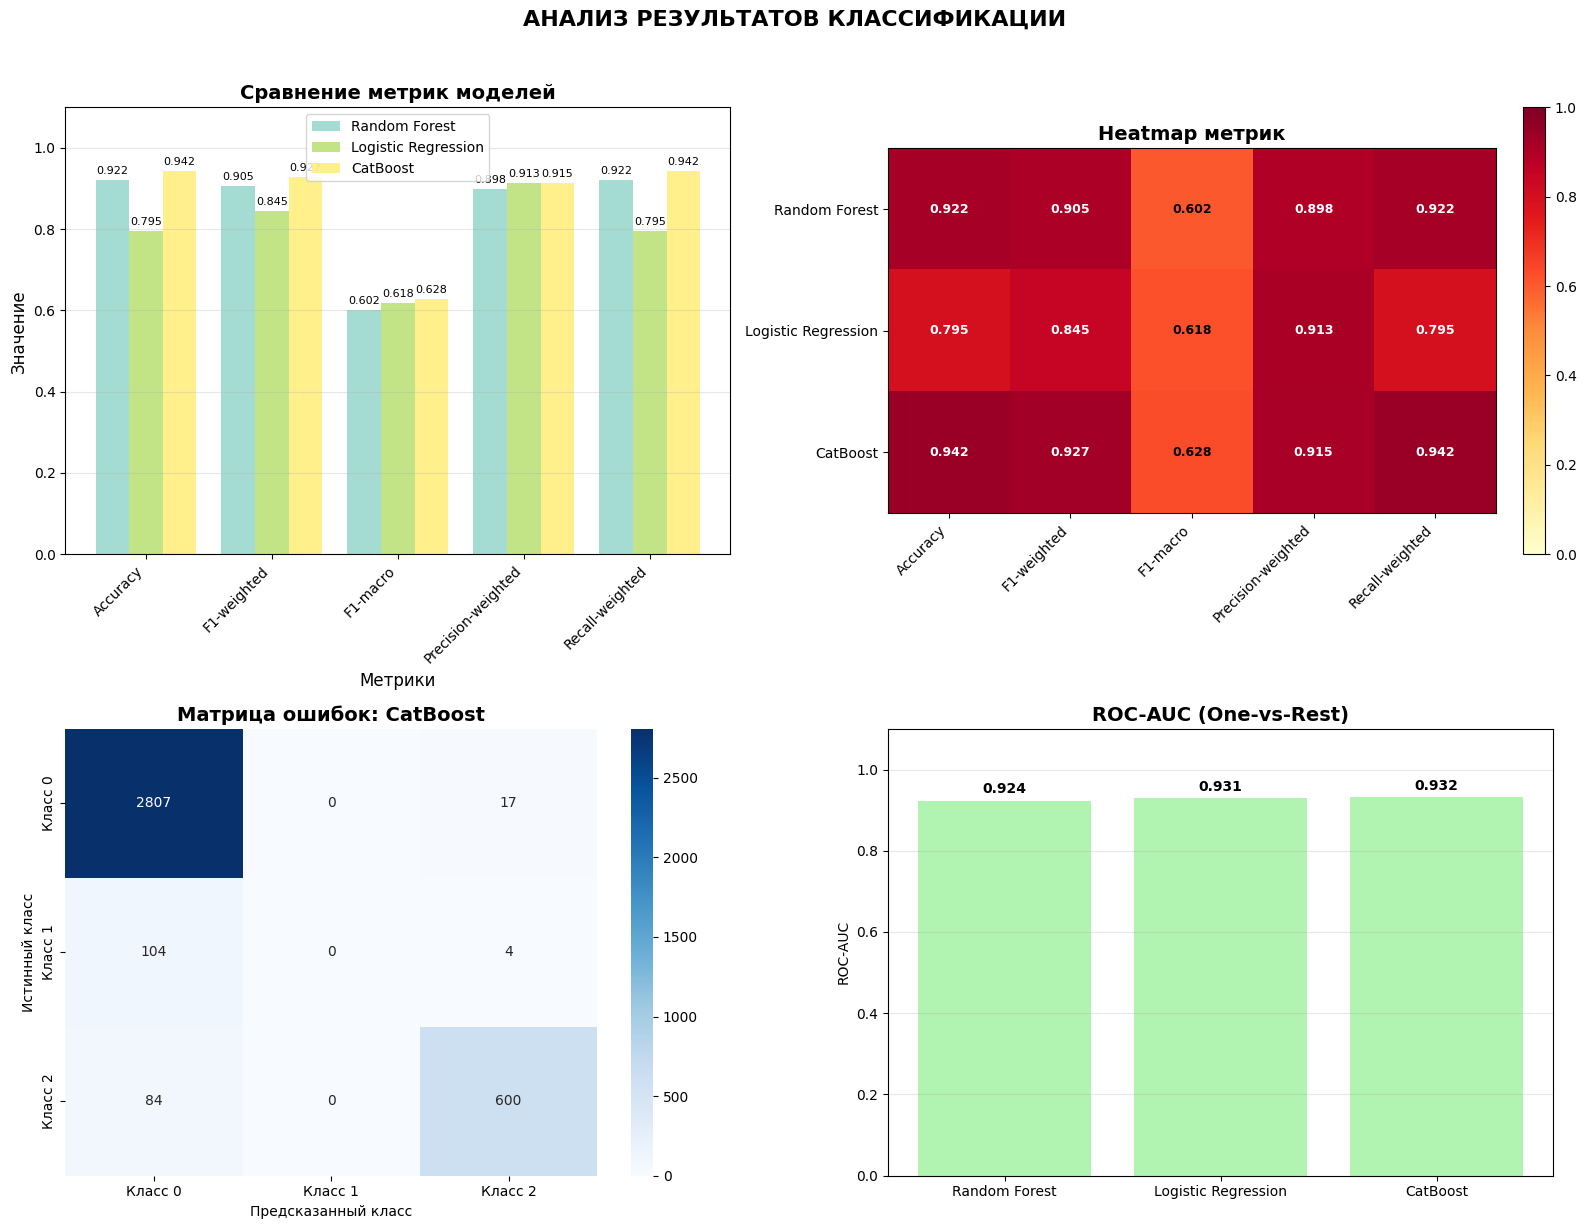


📈 ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА:

🏆 ЛУЧШАЯ МОДЕЛЬ: CatBoost
   Accuracy            : 0.9422
   F1-weighted         : 0.9274
   F1-macro            : 0.6281
   Precision-weighted  : 0.9147
   Recall-weighted     : 0.9422

🔬 КРОСС-ВАЛИДАЦИЯ ДЛЯ ЛУЧШЕЙ МОДЕЛИ:


D:\pars\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
1 fits failed out of a total of 5.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "D:\pars\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "D:\pars\.venv\Lib\site-packages\catboost\core.py", line 5245, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline, use_best_model,
  File "D:\pars\.venv\Lib\site-packages\catboost\core.py", line 2410, in _fit
    self._train(
  File "D:\pars\

   Accuracy (5-fold CV): nan (+/- nan)


D:\pars\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
2 fits failed out of a total of 5.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "D:\pars\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "D:\pars\.venv\Lib\site-packages\catboost\core.py", line 5245, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline, use_best_model,
  File "D:\pars\.venv\Lib\site-packages\catboost\core.py", line 2410, in _fit
    self._train(
  File "D:\pars\

   F1-weighted (5-fold CV): nan (+/- nan)

💾 СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
✅ Random Forest        → sentiment_classification_20251211_022952/random_forest.pkl
✅ Logistic Regression  → sentiment_classification_20251211_022952/logistic_regression.pkl
✅ CatBoost             → sentiment_classification_20251211_022952/catboost.pkl
✅ Метрики сохранены → sentiment_classification_20251211_022952/model_metrics.json
✅ Информация сохранена → sentiment_classification_20251211_022952/training_info.json
✅ Сравнение моделей → sentiment_classification_20251211_022952/model_comparison.csv

📁 Все файлы сохранены в папку: sentiment_classification_20251211_022952

✅ ПАЙПЛАЙН УСПЕШНО ЗАВЕРШЕН!
   Результаты сохранены в: sentiment_classification_20251211_022952

📋 КРАТКИЙ ОТЧЕТ

🏆 ЛУЧШАЯ МОДЕЛЬ: CatBoost

📊 ОСНОВНЫЕ МЕТРИКИ:
   Accuracy            : 0.9422
   F1-weighted         : 0.9274
   F1-macro            : 0.6281
   ROC-AUC (OVR)       : 0.9323

🎯 Для использования модели в продакшене:
   1. Загрузите модель

In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Проверяем наличие CatBoost
try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
    print("✅ CatBoost доступен")
except ImportError:
    CATBOOST_AVAILABLE = False
    print("⚠️ CatBoost не установлен. Установите: pip install catboost")

# 1. Функция для расчета всех метрик
def calculate_all_metrics(y_true, y_pred, y_pred_proba=None):
    """
    Рассчитывает все указанные метрики
    """
    metrics = {}

    # Основные метрики
    metrics['Accuracy'] = accuracy_score(y_true, y_pred)
    metrics['F1-weighted'] = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    metrics['F1-macro'] = f1_score(y_true, y_pred, average='macro', zero_division=0)
    metrics['Precision-weighted'] = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    metrics['Recall-weighted'] = recall_score(y_true, y_pred, average='weighted', zero_division=0)

    # ROC-AUC (только если есть вероятности)
    if y_pred_proba is not None:
        try:
            # Проверяем, что есть минимум 2 класса
            if len(np.unique(y_true)) > 1:
                metrics['ROC-AUC (OVR)'] = roc_auc_score(
                    y_true, y_pred_proba, multi_class='ovr', average='weighted'
                )
            else:
                metrics['ROC-AUC (OVR)'] = None
        except Exception as e:
            metrics['ROC-AUC (OVR)'] = None
            print(f"⚠️ Ошибка ROC-AUC: {e}")
    else:
        metrics['ROC-AUC (OVR)'] = None

    return metrics

# 2. Функция подготовки данных
def prepare_training_data(df, target_column='тональность'):
    """
    Подготавливает данные для обучения
    """
    print(f"🎯 ПОДГОТОВКА ДАННЫХ ДЛЯ ОБУЧЕНИЯ")
    print(f"Целевая переменная: '{target_column}'")
    print("="*60)

    # Проверяем наличие целевой переменной
    if target_column not in df.columns:
        print(f"❌ Целевая переменная '{target_column}' не найдена")
        print(f"   Доступные столбцы: {df.columns.tolist()}")
        return None, None, None

    # Проверяем целевую переменную
    y = df[target_column].values
    unique_classes, class_counts = np.unique(y, return_counts=True)

    print(f"\n📊 АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:")
    print(f"   Количество классов: {len(unique_classes)}")
    print(f"   Классы: {unique_classes}")
    print(f"   Распределение:")
    for cls, cnt in zip(unique_classes, class_counts):
        percentage = cnt / len(y) * 100
        print(f"     Класс {cls}: {cnt} образцов ({percentage:.1f}%)")

    if len(unique_classes) < 2:
        print(f"❌ ОШИБКА: Только 1 класс в данных!")
        return None, None, None

    # Собираем признаки
    features_list = []

    # SBERT векторы
    if 'sbert_vector' in df.columns:
        try:
            sbert_vectors = np.vstack(df['sbert_vector'].values)
            features_list.append(sbert_vectors)
            print(f"✅ SBERT векторы: {sbert_vectors.shape[1]} признаков")
        except Exception as e:
            print(f"⚠️ Ошибка SBERT: {e}")

    # RuBERT-Tiny2 векторы
    if 'rubert_tiny2_vector' in df.columns:
        try:
            rubert_vectors = np.vstack(df['rubert_tiny2_vector'].values)
            features_list.append(rubert_vectors)
            print(f"✅ RuBERT векторы: {rubert_vectors.shape[1]} признаков")
        except Exception as e:
            print(f"⚠️ Ошибка RuBERT: {e}")

    # TF-IDF векторы
    if 'Текст отзыва отчищенный_TFIDF' in df.columns:
        try:
            tfidf_vectors = np.vstack(df['Текст отзыва отчищенный_TFIDF'].values)
            features_list.append(tfidf_vectors)
            print(f"✅ TF-IDF текста: {tfidf_vectors.shape[1]} признаков")
        except Exception as e:
            print(f"⚠️ Ошибка TF-IDF текста: {e}")

    # Количественные признаки
    quant_features = []
    for pattern in ['длина', 'слов', 'предложен']:
        matching = [col for col in df.columns if pattern in col.lower()]
        quant_features.extend(matching)

    quant_features = list(set(quant_features))

    if quant_features:
        try:
            quant_vectors = df[quant_features].values
            features_list.append(quant_vectors)
            print(f"✅ Количественные признаки: {len(quant_features)} признаков")
        except Exception as e:
            print(f"⚠️ Ошибка количественных признаков: {e}")

    # Проверяем, что есть признаки
    if not features_list:
        print("❌ Нет признаков для обучения")
        return None, None, None

    # Объединяем признаки
    X = np.hstack(features_list)

    print(f"\n✅ ПРИЗНАКИ ПОДГОТОВЛЕНЫ:")
    print(f"   Всего признаков: {X.shape[1]}")
    print(f"   Всего образцов: {X.shape[0]}")

    return X, y, unique_classes

# 3. Обучение моделей с полными метриками
def train_models_with_metrics(X, y, test_size=0.2, random_state=42):
    """
    Обучение моделей с расчетом всех метрик
    """
    print(f"\n🚀 ОБУЧЕНИЕ МОДЕЛЕЙ С МЕТРИКАМИ")
    print("="*60)

    # Разделение данных со стратификацией
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    print(f"📊 РАЗДЕЛЕНИЕ ДАННЫХ:")
    print(f"   Обучающая выборка: {X_train.shape}")
    print(f"   Тестовая выборка: {X_test.shape}")

    # Словарь для хранения результатов
    all_results = {}

    # 1. Random Forest
    print(f"\n{'='*50}")
    print("🔹 1. RANDOM FOREST")
    print(f"{'='*50}")

    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=random_state,
        n_jobs=-1
    )

    rf_model.fit(X_train, y_train)

    # Предсказания и вероятности
    y_pred_rf = rf_model.predict(X_test)
    y_pred_proba_rf = rf_model.predict_proba(X_test)

    # Рассчитываем все метрики
    rf_metrics = calculate_all_metrics(y_test, y_pred_rf, y_pred_proba_rf)

    all_results['Random Forest'] = {
        'model': rf_model,
        'predictions': y_pred_rf,
        'probabilities': y_pred_proba_rf,
        'metrics': rf_metrics
    }

    # Выводим метрики
    print(f"\n📈 МЕТРИКИ Random Forest:")
    for metric_name, value in rf_metrics.items():
        if value is not None:
            print(f"   {metric_name:20}: {value:.4f}")

    print(f"\n📋 Classification Report:")
    print(classification_report(y_test, y_pred_rf,
                              target_names=[f'Класс {i}' for i in np.unique(y)],
                              zero_division=0))

    # 2. Logistic Regression
    print(f"\n{'='*50}")
    print("🔹 2. LOGISTIC REGRESSION")
    print(f"{'='*50}")

    lr_model = LogisticRegression(
        max_iter=1000,
        C=1.0,
        class_weight='balanced',
        random_state=random_state,
        solver='lbfgs',
        multi_class='multinomial',
        n_jobs=-1
    )

    lr_model.fit(X_train, y_train)

    # Предсказания и вероятности
    y_pred_lr = lr_model.predict(X_test)
    y_pred_proba_lr = lr_model.predict_proba(X_test)

    # Рассчитываем все метрики
    lr_metrics = calculate_all_metrics(y_test, y_pred_lr, y_pred_proba_lr)

    all_results['Logistic Regression'] = {
        'model': lr_model,
        'predictions': y_pred_lr,
        'probabilities': y_pred_proba_lr,
        'metrics': lr_metrics
    }

    # Выводим метрики
    print(f"\n📈 МЕТРИКИ Logistic Regression:")
    for metric_name, value in lr_metrics.items():
        if value is not None:
            print(f"   {metric_name:20}: {value:.4f}")

    print(f"\n📋 Classification Report:")
    print(classification_report(y_test, y_pred_lr,
                              target_names=[f'Класс {i}' for i in np.unique(y)],
                              zero_division=0))

    # 3. CatBoost (если доступен)
    if CATBOOST_AVAILABLE:
        print(f"\n{'='*50}")
        print("🔹 3. CATBOOST")
        print(f"{'='*50}")

        catboost_model = CatBoostClassifier(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            l2_leaf_reg=3,
            loss_function='MultiClass',
            eval_metric='Accuracy',
            random_seed=random_state,
            verbose=False,
            task_type='CPU'
        )

        try:
            catboost_model.fit(
                X_train, y_train,
                eval_set=(X_test, y_test),
                early_stopping_rounds=50,
                use_best_model=True,
                verbose=False
            )

            # Предсказания и вероятности
            y_pred_cb = catboost_model.predict(X_test)
            y_pred_cb = y_pred_cb.reshape(-1)
            y_pred_proba_cb = catboost_model.predict_proba(X_test)

            # Рассчитываем все метрики
            cb_metrics = calculate_all_metrics(y_test, y_pred_cb, y_pred_proba_cb)

            all_results['CatBoost'] = {
                'model': catboost_model,
                'predictions': y_pred_cb,
                'probabilities': y_pred_proba_cb,
                'metrics': cb_metrics
            }

            # Выводим метрики
            print(f"\n📈 МЕТРИКИ CatBoost:")
            for metric_name, value in cb_metrics.items():
                if value is not None:
                    print(f"   {metric_name:20}: {value:.4f}")

            print(f"\n📋 Classification Report:")
            print(classification_report(y_test, y_pred_cb,
                                      target_names=[f'Класс {i}' for i in np.unique(y)],
                                      zero_division=0))

        except Exception as e:
            print(f"❌ Ошибка CatBoost: {e}")

    # Сравнение всех моделей
    print(f"\n{'='*60}")
    print("🏆 СРАВНЕНИЕ МОДЕЛЕЙ ПО МЕТРИКАМ")
    print(f"{'='*60}")

    # Создаем таблицу сравнения
    comparison_data = []
    metric_columns = ['Accuracy', 'F1-weighted', 'F1-macro',
                     'Precision-weighted', 'Recall-weighted', 'ROC-AUC (OVR)']

    for model_name, result in all_results.items():
        row = {'Модель': model_name}
        for metric in metric_columns:
            value = result['metrics'].get(metric)
            row[metric] = f"{value:.4f}" if value is not None else "N/A"
        comparison_data.append(row)

    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.to_string(index=False))

    # Определяем лучшую модель по F1-weighted (основная метрика)
    best_model_name = None
    best_f1_weighted = -1

    for model_name, result in all_results.items():
        f1_weighted = result['metrics'].get('F1-weighted')
        if f1_weighted is not None and f1_weighted > best_f1_weighted:
            best_f1_weighted = f1_weighted
            best_model_name = model_name

    if best_model_name:
        print(f"\n🏅 ЛУЧШАЯ МОДЕЛЬ (по F1-weighted): {best_model_name}")
        print(f"   F1-weighted: {best_f1_weighted:.4f}")

    return {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'results': all_results,
        'comparison_df': comparison_df,
        'best_model': best_model_name
    }

# 4. Визуализация метрик
def visualize_model_metrics(training_results):
    """
    Визуализация метрик моделей
    """
    print(f"\n📊 ВИЗУАЛИЗАЦИЯ МЕТРИК МОДЕЛЕЙ")
    print("="*60)

    results = training_results['results']

    if not results:
        print("❌ Нет результатов для визуализации")
        return

    # Основные метрики для сравнения
    metric_names = ['Accuracy', 'F1-weighted', 'F1-macro',
                   'Precision-weighted', 'Recall-weighted']

    # Создаем данные для графика
    model_names = list(results.keys())
    n_models = len(model_names)
    n_metrics = len(metric_names)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Сравнение всех метрик (горизонтальные столбцы)
    ax1 = axes[0, 0]

    x = np.arange(n_metrics)
    width = 0.8 / n_models

    colors = plt.cm.Set3(np.linspace(0, 1, n_models))

    for i, model_name in enumerate(model_names):
        metrics_values = []
        for metric in metric_names:
            value = results[model_name]['metrics'].get(metric)
            metrics_values.append(value if value is not None else 0)

        bars = ax1.bar(x + i*width, metrics_values, width,
                      label=model_name, color=colors[i], alpha=0.8)

        # Добавляем значения
        for bar, val in zip(bars, metrics_values):
            if val > 0:
                height = bar.get_height()
                ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=8)

    ax1.set_xlabel('Метрики', fontsize=12)
    ax1.set_ylabel('Значение', fontsize=12)
    ax1.set_title('Сравнение метрик моделей', fontsize=14, fontweight='bold')
    ax1.set_xticks(x + width * (n_models - 1) / 2)
    ax1.set_xticklabels(metric_names, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    ax1.set_ylim([0, 1.1])

    # 2. Heatmap метрик
    ax2 = axes[0, 1]

    # Подготовка данных для heatmap
    heatmap_data = []
    for model_name in model_names:
        row = []
        for metric in metric_names:
            value = results[model_name]['metrics'].get(metric)
            row.append(value if value is not None else 0)
        heatmap_data.append(row)

    heatmap_data = np.array(heatmap_data)

    im = ax2.imshow(heatmap_data, cmap='YlOrRd', vmin=0, vmax=1)

    # Настройки heatmap
    ax2.set_xticks(np.arange(len(metric_names)))
    ax2.set_yticks(np.arange(len(model_names)))
    ax2.set_xticklabels(metric_names, rotation=45, ha='right')
    ax2.set_yticklabels(model_names)

    # Добавляем значения в ячейки
    for i in range(len(model_names)):
        for j in range(len(metric_names)):
            text = ax2.text(j, i, f'{heatmap_data[i, j]:.3f}',
                          ha='center', va='center',
                          color='black' if heatmap_data[i, j] < 0.7 else 'white',
                          fontsize=9, fontweight='bold')

    ax2.set_title('Heatmap метрик', fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)

    # 3. Матрица ошибок для лучшей модели
    ax3 = axes[1, 0]

    best_model_name = training_results.get('best_model')
    if best_model_name:
        y_test = training_results['y_test']
        y_pred = results[best_model_name]['predictions']

        cm = confusion_matrix(y_test, y_pred)

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
                   xticklabels=[f'Класс {i}' for i in np.unique(y_test)],
                   yticklabels=[f'Класс {i}' for i in np.unique(y_test)])

        ax3.set_title(f'Матрица ошибок: {best_model_name}',
                     fontsize=14, fontweight='bold')
        ax3.set_xlabel('Предсказанный класс')
        ax3.set_ylabel('Истинный класс')
    else:
        ax3.text(0.5, 0.5, 'Нет данных',
                ha='center', va='center', fontsize=14)
        ax3.set_title('Матрица ошибок', fontsize=14, fontweight='bold')

    # 4. ROC-AUC метрики (если есть)
    ax4 = axes[1, 1]

    roc_values = []
    roc_labels = []

    for model_name in model_names:
        roc_auc = results[model_name]['metrics'].get('ROC-AUC (OVR)')
        if roc_auc is not None:
            roc_values.append(roc_auc)
            roc_labels.append(model_name)

    if roc_values:
        bars = ax4.bar(roc_labels, roc_values, color='lightgreen', alpha=0.7)
        ax4.set_title('ROC-AUC (One-vs-Rest)', fontsize=14, fontweight='bold')
        ax4.set_ylabel('ROC-AUC')
        ax4.set_ylim([0, 1.1])
        ax4.grid(axis='y', alpha=0.3)

        # Добавляем значения
        for bar, val in zip(bars, roc_values):
            height = bar.get_height()
            ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
    else:
        ax4.text(0.5, 0.5, 'ROC-AUC недоступен',
                ha='center', va='center', fontsize=14)
        ax4.set_title('ROC-AUC метрики', fontsize=14, fontweight='bold')

    plt.suptitle('АНАЛИЗ РЕЗУЛЬТАТОВ КЛАССИФИКАЦИИ',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Дополнительная статистика
    print(f"\n📈 ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА:")

    if best_model_name:
        best_metrics = results[best_model_name]['metrics']
        print(f"\n🏆 ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
        for metric_name in metric_names:
            value = best_metrics.get(metric_name)
            if value is not None:
                print(f"   {metric_name:20}: {value:.4f}")

    # Кросс-валидация для лучшей модели
    if best_model_name:
        print(f"\n🔬 КРОСС-ВАЛИДАЦИЯ ДЛЯ ЛУЧШЕЙ МОДЕЛИ:")

        best_model = results[best_model_name]['model']
        X_full = np.vstack([training_results['X_train'],
                           training_results['X_test']])
        y_full = np.concatenate([training_results['y_train'],
                                training_results['y_test']])

        try:
            cv_scores = cross_val_score(best_model, X_full, y_full,
                                      cv=5, scoring='accuracy', n_jobs=-1)
            print(f"   Accuracy (5-fold CV): {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

            # F1-weighted кросс-валидация
            cv_f1 = cross_val_score(best_model, X_full, y_full,
                                  cv=5, scoring='f1_weighted', n_jobs=-1)
            print(f"   F1-weighted (5-fold CV): {cv_f1.mean():.4f} (+/- {cv_f1.std()*2:.4f})")

        except Exception as e:
            print(f"   Ошибка кросс-валидации: {e}")

# 5. Сохранение результатов
def save_training_results(training_results, filename_prefix='sentiment_classification'):
    """
    Сохранение результатов обучения
    """
    print(f"\n💾 СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
    print("="*60)

    import joblib
    import json
    import os
    from datetime import datetime

    # Создаем папку для сохранения
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_dir = f"{filename_prefix}_{timestamp}"
    os.makedirs(save_dir, exist_ok=True)

    results = training_results['results']

    # Сохраняем каждую модель
    saved_models = []
    for model_name, result in results.items():
        model = result['model']
        model_filename = f"{save_dir}/{model_name.lower().replace(' ', '_')}.pkl"
        joblib.dump(model, model_filename)
        saved_models.append(model_filename)
        print(f"✅ {model_name:20} → {model_filename}")

    # Сохраняем метрики
    metrics_data = {}
    for model_name, result in results.items():
        metrics_data[model_name] = {}
        for metric_name, value in result['metrics'].items():
            if value is not None:
                metrics_data[model_name][metric_name] = float(value)

    metrics_filename = f"{save_dir}/model_metrics.json"
    with open(metrics_filename, 'w', encoding='utf-8') as f:
        json.dump(metrics_data, f, indent=2, ensure_ascii=False)

    print(f"✅ Метрики сохранены → {metrics_filename}")

    # Сохраняем полную информацию
    full_info = {
        'training_date': timestamp,
        'best_model': training_results.get('best_model'),
        'data_shape': {
            'train': training_results['X_train'].shape,
            'test': training_results['X_test'].shape,
            'total_features': training_results['X_train'].shape[1]
        },
        'class_distribution': {
            'train': {int(k): int(v) for k, v in zip(*np.unique(training_results['y_train'], return_counts=True))},
            'test': {int(k): int(v) for k, v in zip(*np.unique(training_results['y_test'], return_counts=True))}
        }
    }

    info_filename = f"{save_dir}/training_info.json"
    with open(info_filename, 'w', encoding='utf-8') as f:
        json.dump(full_info, f, indent=2, ensure_ascii=False)

    print(f"✅ Информация сохранена → {info_filename}")

    # Сохраняем comparison dataframe
    if 'comparison_df' in training_results:
        csv_filename = f"{save_dir}/model_comparison.csv"
        training_results['comparison_df'].to_csv(csv_filename, index=False, encoding='utf-8-sig')
        print(f"✅ Сравнение моделей → {csv_filename}")

    print(f"\n📁 Все файлы сохранены в папку: {save_dir}")
    return save_dir

# 6. ЗАПУСК ВСЕГО ПРОЦЕССА
def run_full_training_pipeline(df, target_column='тональность'):
    """
    Запуск полного пайплайна обучения
    """
    print(f"\n{'='*70}")
    print("🚀 ЗАПУСК ПОЛНОГО ПАЙПЛАЙНА ОБУЧЕНИЯ")
    print(f"{'='*70}")

    # 1. Подготовка данных
    X, y, classes = prepare_training_data(df, target_column)

    if X is None:
        print("❌ Ошибка подготовки данных")
        return None

    # 2. Обучение моделей
    training_results = train_models_with_metrics(X, y)

    if training_results is None:
        print("❌ Ошибка обучения моделей")
        return None

    # 3. Визуализация результатов
    visualize_model_metrics(training_results)

    # 4. Сохранение результатов
    save_dir = save_training_results(training_results)

    print(f"\n✅ ПАЙПЛАЙН УСПЕШНО ЗАВЕРШЕН!")
    print(f"   Результаты сохранены в: {save_dir}")

    return training_results

# ЗАПУСКАЕМ ВСЁ
print("🚀 ЗАПУСК ОБУЧЕНИЯ МОДЕЛЕЙ ДЛЯ КЛАССИФИКАЦИИ ТОНАЛЬНОСТИ")
print("="*70)

# Проверяем наличие целевого столбца
if 'тональность' not in improved_baseline_dataset.columns:
    print(f"❌ Столбец 'тональность' не найден!")
    print(f"   Доступные столбцы: {improved_baseline_dataset.columns.tolist()}")

    # Ищем альтернативные названия
    possible_targets = [col for col in improved_baseline_dataset.columns
                       if any(word in col.lower() for word in ['тональност', 'оценк', 'рейтинг', 'target', 'класс'])]

    if possible_targets:
        print(f"\n🔍 Найдены возможные целевые переменные:")
        for col in possible_targets:
            unique_vals = improved_baseline_dataset[col].nunique()
            print(f"   - {col} ({unique_vals} уникальных значений)")

        # Используем первую найденную
        target_column = possible_targets[0]
        print(f"\n⚠️  Используем '{target_column}' как целевую переменную")
    else:
        print("❌ Не найдено подходящих целевых переменных")
        target_column = None
else:
    target_column = 'тональность'

if target_column:
    # Запускаем пайплайн
    results = run_full_training_pipeline(improved_baseline_dataset, target_column)

    if results:
        # Краткий отчет
        print(f"\n{'='*70}")
        print("📋 КРАТКИЙ ОТЧЕТ")
        print(f"{'='*70}")

        best_model = results.get('best_model')
        if best_model:
            best_metrics = results['results'][best_model]['metrics']

            print(f"\n🏆 ЛУЧШАЯ МОДЕЛЬ: {best_model}")
            print(f"\n📊 ОСНОВНЫЕ МЕТРИКИ:")
            for metric in ['Accuracy', 'F1-weighted', 'F1-macro', 'ROC-AUC (OVR)']:
                value = best_metrics.get(metric)
                if value is not None:
                    print(f"   {metric:20}: {value:.4f}")

        print(f"\n🎯 Для использования модели в продакшене:")
        print(f"   1. Загрузите модель из сохраненной папки")
        print(f"   2. Используйте model.predict() для новых данных")
        print(f"   3. Используйте model.predict_proba() для получения вероятностей")

In [39]:
import torch
torch.cuda.is_available()

True

НАСТРОЙКА CUDA ДЛЯ УСКОРЕННОЙ ОБРАБОТКИ
PyTorch version: 2.9.1+cu130
CUDA available: True
Number of CUDA devices: 1
  Device 0: NVIDIA GeForce RTX 3070 Ti Laptop GPU (8.59 GB)

Использую устройство: NVIDIA GeForce RTX 3070 Ti Laptop GPU
Кэш CUDA очищен

ЗАГРУЗКА МОДЕЛИ НА CUDA
Загружаю модель: cointegrated/rubert-tiny-sentiment-balanced


tokenizer_config.json:   0%|          | 0.00/377 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/47.2M [00:00<?, ?B/s]

Модель переведена в половинную точность (FP16)
Модель загружена на: cuda:0

Память GPU:
  Выделено: 0.74 GB / 8.59 GB
  Зарезервировано: 0.81 GB
  Свободно: 7.85 GB

ПРИМЕНЕНИЕ МОДЕЛИ К ДАТАФРЕЙМУ (CUDA УСКОРЕНИЕ)
Размер датафрейма: 18,077 записей

Оптимальные параметры для вашего GPU:
  Размер батча: 128
  Максимальная длина текста: 256

🚀 Начинаю обработку на CUDA...

Обрабатываю 18,077 текстов на CUDA...
Размер батча: 128
Максимальная длина: 256
Смешанная точность: Включена


Обработка на CUDA:   0%|          | 0/18077 [00:00<?, ?текст/s]


✅ Обработка завершена за 14.5 секунд
Скорость обработки: 1245.4 текстов/сек

Память GPU:
  Выделено: 0.62 GB / 8.59 GB
  Зарезервировано: 0.99 GB
  Свободно: 7.97 GB

ПРЕОБРАЗОВАНИЕ МЕТОК И ПОДГОТОВКА ДАННЫХ
Пропущенных предсказаний: 0 (0.00%)

📊 Статистика датасета для оценки:
  Всего записей: 18,077
  Для оценки: 18,077
  Отфильтровано: 0

ВЫЧИСЛЕНИЕ МЕТРИК КАЧЕСТВА

📈 РАСПРЕДЕЛЕНИЕ МЕТОК:
--------------------------------------------------
Истинные метки:
  негатив (0): 14,118 ( 78.1%)
  нейтрал (1):    538 (  3.0%)
  позитив (2):  3,421 ( 18.9%)

Предсказанные метки:
  негатив (0):  7,708 ( 42.6%)
  нейтрал (1):  8,194 ( 45.3%)
  позитив (2):  2,175 ( 12.0%)

🎯 ОСНОВНЫЕ МЕТРИКИ:
--------------------------------------------------
Accuracy:           0.4878
F1-weighted:        0.6072
F1-macro:           0.4198
Precision-weighted: 0.8444
Recall-weighted:    0.4878

📊 ДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССАМ:
--------------------------------------------------
              precision    recall  f1-sc

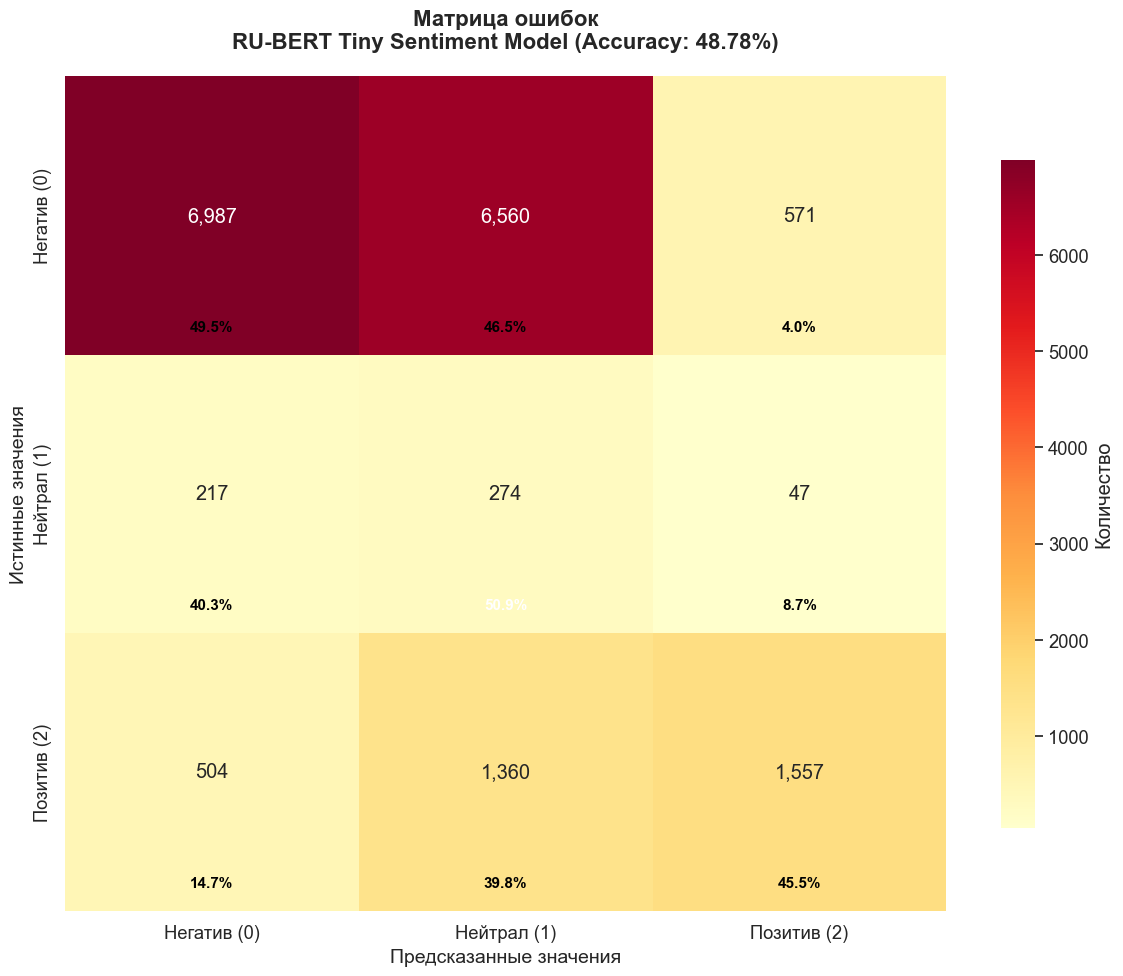

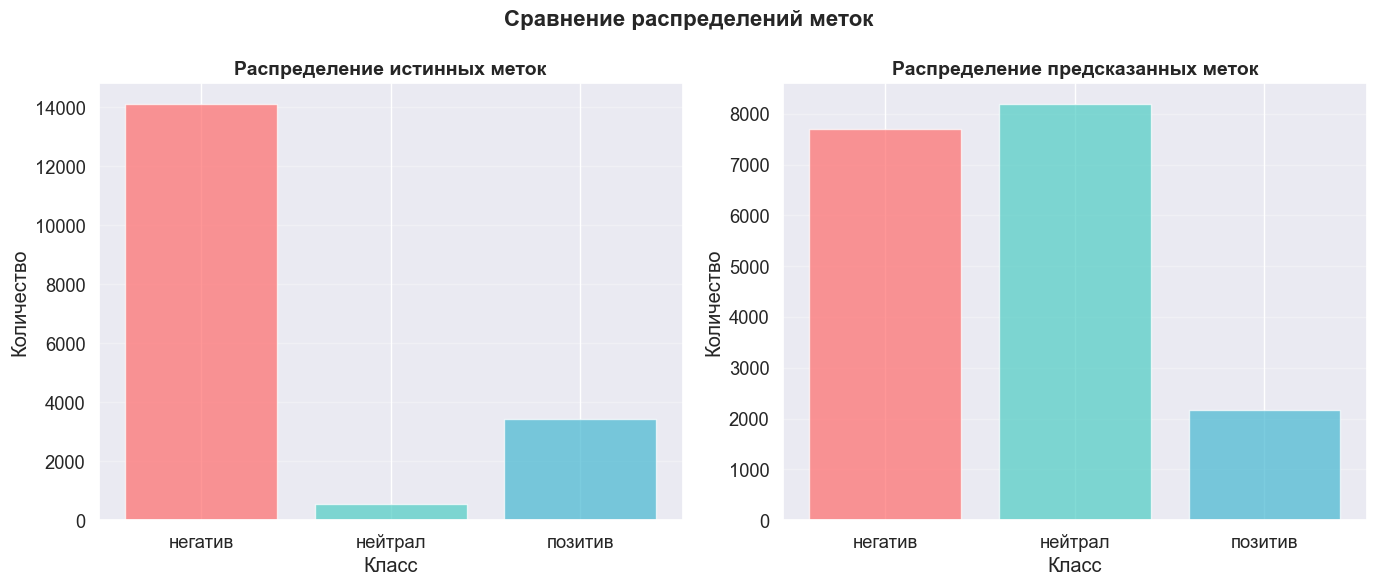

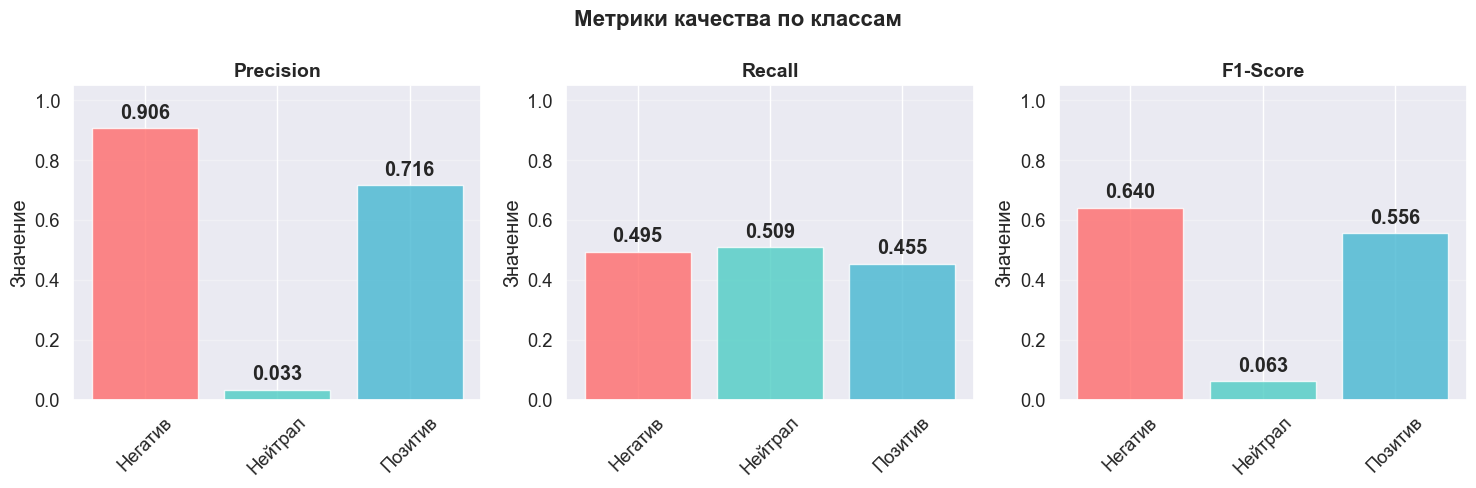


ДЕТАЛЬНЫЙ АНАЛИЗ ОШИБОК

📉 СТАТИСТИКА ОШИБОК:
  Всего ошибок: 9,259
  Общая точность: 48.78%
  Частота ошибок: 51.22%

🔍 МАТРИЦА ОШИБОК (только ошибочные предсказания):
------------------------------------------------------------
Истинный → Предсказанный | Количество | % от всех ошибок
------------------------------------------------------------
  негатив→нейтрал |      6,560 |  70.85%
  позитив→нейтрал |      1,360 |  14.69%
  негатив→позитив |        571 |   6.17%
  позитив→негатив |        504 |   5.44%
  нейтрал→негатив |        217 |   2.34%
  нейтрал→позитив |         47 |   0.51%

⚠️  ПРОБЛЕМНЫЕ КЛАССЫ:
  негатив: 50.51% ошибок
    Чаще всего путают с нейтрал (6560 раз)
  нейтрал: 49.07% ошибок
    Чаще всего путают с негатив (217 раз)
  позитив: 54.49% ошибок
    Чаще всего путают с нейтрал (1360 раз)

ПРИМЕРЫ ПРЕДСКАЗАНИЙ

Показываю 5 случайных примеров:
--------------------------------------------------------------------------------

1. ❌ ОШИБКА
   Текст: хотел бы поделиться

Вычисление вероятностей:   0%|          | 0/1000 [00:00<?, ?текст/s]


💾 Сохраняю датафрейм в improved_baseline_dataset_with_predictions_cuda.csv...
✅ Датафрейм сохранен: improved_baseline_dataset_with_predictions_cuda.csv
   Размер: 18,077 записей
   Размер файла: 1107.4 MB

📄 Создаю сводный отчет: model_evaluation_summary_cuda.txt
✅ Отчет сохранен: model_evaluation_summary_cuda.txt

ФИНАЛЬНАЯ СТАТИСТИКА И ОЧИСТКА ПАМЯТИ
✅ Память GPU очищена

📊 ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ:
  Всего записей:           18,077
  Успешно оценено:         18,077
  Правильных предсказаний: 8,818
  Точность модели:         48.78%
  Ошибок:                  9,259

🎉 ОБРАБОТКА ЗАВЕРШЕНА УСПЕШНО!

Итоговая точность модели: 48.78%
Время обработки: 14.5 секунд
Скорость: 1245.4 текстов/сек

✅ CUDA успешно использовалась для ускорения вычислений!
   Устройство: NVIDIA GeForce RTX 3070 Ti Laptop GPU

📁 Результаты сохранены в файлах:
   1. improved_baseline_dataset_with_predictions_cuda.csv - данные с предсказаниями
   2. model_evaluation_summary_cuda.txt - сводный отчет
   3. *.png файлы - ви

In [40]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix, precision_recall_fscore_support
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm.auto import tqdm
import warnings
import gc
warnings.filterwarnings('ignore')

# Очистка памяти GPU перед началом
torch.cuda.empty_cache()
gc.collect()

# ============================================================================
# 1. ПРОВЕРКА И НАСТРОЙКА CUDA
# ============================================================================
print("=" * 70)
print("НАСТРОЙКА CUDA ДЛЯ УСКОРЕННОЙ ОБРАБОТКИ")
print("=" * 70)

# Проверяем доступность CUDA
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    device_count = torch.cuda.device_count()
    print(f"Number of CUDA devices: {device_count}")

    for i in range(device_count):
        device_name = torch.cuda.get_device_name(i)
        device_memory = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f"  Device {i}: {device_name} ({device_memory:.2f} GB)")

    # Выбираем устройство
    device = torch.device('cuda:0')
    print(f"\nИспользую устройство: {torch.cuda.get_device_name(0)}")

    # Оптимизация для CUDA
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

    # Очищаем кэш перед началом
    torch.cuda.empty_cache()
    print("Кэш CUDA очищен")
else:
    device = torch.device('cpu')
    print("CUDA недоступна, использую CPU")

# ============================================================================
# 2. ЗАГРУЗКА И НАСТРОЙКА МОДЕЛИ С ОПТИМИЗАЦИЕЙ ДЛЯ CUDA
# ============================================================================
print("\n" + "=" * 70)
print("ЗАГРУЗКА МОДЕЛИ НА CUDA")
print("=" * 70)

model_checkpoint = 'cointegrated/rubert-tiny-sentiment-balanced'
print(f"Загружаю модель: {model_checkpoint}")

# Загрузка с оптимизацией
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint)

# Перенос модели на GPU с оптимизацией
model.to(device)
model.eval()  # Важно для инференса

# Оптимизация для инференса
if torch.cuda.is_available():
    model.half()  # Используем половинную точность для экономии памяти
    print("Модель переведена в половинную точность (FP16)")

print(f"Модель загружена на: {next(model.parameters()).device}")

# ============================================================================
# 3. ОПТИМИЗИРОВАННЫЕ ФУНКЦИИ ДЛЯ ПРЕДСКАЗАНИЙ НА CUDA
# ============================================================================
def get_sentiment_cuda(text, return_type='label'):
    """Расчет тональности текста с оптимизацией для CUDA"""
    with torch.no_grad():
        # Используем autocast для смешанной точности
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True).to(device)
            proba = torch.sigmoid(model(**inputs).logits).cpu().numpy()[0]

    if return_type == 'label':
        return model.config.id2label[proba.argmax()]
    elif return_type == 'score':
        return proba.dot([-1, 0, 1])
    return proba

def predict_sentiment_batch_cuda(texts, batch_size=128, max_length=256, use_amp=True):
    """
    Оптимизированная батчевая обработка на CUDA
    с поддержкой автоматической смешанной точности
    """
    predictions = []

    print(f"\nОбрабатываю {len(texts):,} текстов на CUDA...")
    print(f"Размер батча: {batch_size}")
    print(f"Максимальная длина: {max_length}")
    print(f"Смешанная точность: {'Включена' if use_amp and torch.cuda.is_available() else 'Выключена'}")

    # Создаем scaler для смешанной точности
    scaler = torch.cuda.amp.GradScaler() if use_amp and torch.cuda.is_available() else None

    with tqdm(total=len(texts), desc="Обработка на CUDA", unit="текст",
              bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]') as pbar:

        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            valid_texts = []
            valid_indices = []

            # Фильтрация валидных текстов
            for j, text in enumerate(batch_texts):
                if isinstance(text, str) and str(text).strip():
                    valid_texts.append(str(text))
                    valid_indices.append(j)

            if valid_texts:
                try:
                    # Токенизация всего батча
                    inputs = tokenizer(
                        valid_texts,
                        return_tensors='pt',
                        truncation=True,
                        padding=True,
                        max_length=max_length
                    ).to(device)

                    # Предсказание с оптимизацией
                    with torch.no_grad():
                        if scaler is not None:
                            with torch.cuda.amp.autocast():
                                outputs = model(**inputs)
                                probas = torch.sigmoid(outputs.logits).cpu().float().numpy()
                        else:
                            outputs = model(**inputs)
                            probas = torch.sigmoid(outputs.logits).cpu().numpy()

                    # Получение меток
                    batch_preds = [model.config.id2label[p.argmax()] for p in probas]

                    # Восстановление порядка
                    full_batch_preds = [None] * len(batch_texts)
                    for idx, pred in zip(valid_indices, batch_preds):
                        full_batch_preds[idx] = pred

                    predictions.extend(full_batch_preds)

                except torch.cuda.OutOfMemoryError:
                    print(f"\n⚠️  Недостаточно памяти GPU при батче {i//batch_size}")
                    print("Уменьшаю размер батча и очищаю память...")

                    # Очищаем память
                    torch.cuda.empty_cache()
                    gc.collect()

                    # Пробуем с меньшим батчем
                    reduced_batch_size = batch_size // 2
                    print(f"Пробую с batch_size={reduced_batch_size}")

                    # Рекурсивно обрабатываем этот батч с меньшим размером
                    retry_predictions = predict_sentiment_batch_cuda(
                        batch_texts,
                        batch_size=reduced_batch_size,
                        max_length=max_length,
                        use_amp=False  # Отключаем AMP для надежности
                    )
                    predictions.extend(retry_predictions)

            else:
                predictions.extend([None] * len(batch_texts))

            pbar.update(len(batch_texts))

            # Периодическая очистка памяти
            if (i // batch_size) % 20 == 0 and torch.cuda.is_available():
                torch.cuda.empty_cache()
                gc.collect()

    return predictions

# ============================================================================
# 4. ОЦЕНКА ПАМЯТИ GPU
# ============================================================================
def print_gpu_memory():
    """Вывод информации о памяти GPU"""
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1e9
        reserved = torch.cuda.memory_reserved() / 1e9
        total = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"\nПамять GPU:")
        print(f"  Выделено: {allocated:.2f} GB / {total:.2f} GB")
        print(f"  Зарезервировано: {reserved:.2f} GB")
        print(f"  Свободно: {total - allocated:.2f} GB")

print_gpu_memory()

# ============================================================================
# 5. ПРИМЕНЕНИЕ МОДЕЛИ К ДАТАФРЕЙМУ С ОПТИМИЗАЦИЕЙ ДЛЯ CUDA
# ============================================================================
print("\n" + "=" * 70)
print("ПРИМЕНЕНИЕ МОДЕЛИ К ДАТАФРЕЙМУ (CUDA УСКОРЕНИЕ)")
print("=" * 70)

print(f"Размер датафрейма: {len(improved_baseline_dataset):,} записей")

# Определяем оптимальный размер батча в зависимости от памяти GPU
if torch.cuda.is_available():
    gpu_memory_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    if gpu_memory_gb >= 16:  # 16GB+ VRAM
        batch_size = 256
        max_length = 512
    elif gpu_memory_gb >= 8:  # 8GB VRAM
        batch_size = 128
        max_length = 256
    else:  # Меньше 8GB
        batch_size = 64
        max_length = 128
else:
    batch_size = 32
    max_length = 256

print(f"\nОптимальные параметры для вашего GPU:")
print(f"  Размер батча: {batch_size}")
print(f"  Максимальная длина текста: {max_length}")

# Получаем предсказания с оптимизацией для CUDA
print("\n🚀 Начинаю обработку на CUDA...")
start_time = pd.Timestamp.now()

improved_baseline_dataset['предсказание_модели'] = predict_sentiment_batch_cuda(
    texts=improved_baseline_dataset['Текст отзыва отчищенный'].tolist(),
    batch_size=batch_size,
    max_length=max_length,
    use_amp=True
)

end_time = pd.Timestamp.now()
processing_time = (end_time - start_time).total_seconds()

print(f"\n✅ Обработка завершена за {processing_time:.1f} секунд")
print(f"Скорость обработки: {len(improved_baseline_dataset)/processing_time:.1f} текстов/сек")

print_gpu_memory()

# ============================================================================
# 6. ПРЕОБРАЗОВАНИЕ И ПОДГОТОВКА ДАННЫХ
# ============================================================================
print("\n" + "=" * 70)
print("ПРЕОБРАЗОВАНИЕ МЕТОК И ПОДГОТОВКА ДАННЫХ")
print("=" * 70)

# Маппинг меток
label_mapping = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}
reverse_mapping = {v: k for k, v in label_mapping.items()}
numeric_labels = {0: 'негатив', 1: 'нейтрал', 2: 'позитив'}

# Создаем числовые версии предсказаний
improved_baseline_dataset['предсказание_числовое'] = improved_baseline_dataset['предсказание_модели'].map(label_mapping)

# Проверяем пропуски
null_count = improved_baseline_dataset['предсказание_модели'].isnull().sum()
print(f"Пропущенных предсказаний: {null_count} ({null_count/len(improved_baseline_dataset)*100:.2f}%)")

# Для оценки удаляем строки с пропусками
df_eval = improved_baseline_dataset.dropna(subset=['тональность', 'предсказание_числовое']).copy()
df_eval['тональность'] = df_eval['тональность'].astype(int)
df_eval['предсказание_числовое'] = df_eval['предсказание_числовое'].astype(int)

print(f"\n📊 Статистика датасета для оценки:")
print(f"  Всего записей: {len(improved_baseline_dataset):,}")
print(f"  Для оценки: {len(df_eval):,}")
print(f"  Отфильтровано: {len(improved_baseline_dataset) - len(df_eval):,}")

# ============================================================================
# 7. ВЫЧИСЛЕНИЕ МЕТРИК С ОПТИМИЗАЦИЕЙ
# ============================================================================
print("\n" + "=" * 70)
print("ВЫЧИСЛЕНИЕ МЕТРИК КАЧЕСТВА")
print("=" * 70)

# Подготовка данных
y_true = df_eval['тональность'].values
y_pred = df_eval['предсказание_числовое'].values

# Распределение меток
print("\n📈 РАСПРЕДЕЛЕНИЕ МЕТОК:")
print("-" * 50)

true_counts = np.bincount(y_true, minlength=3)
pred_counts = np.bincount(y_pred, minlength=3)

print("Истинные метки:")
for i in range(3):
    pct = true_counts[i] / len(y_true) * 100
    print(f"  {numeric_labels[i]} ({i}): {true_counts[i]:6,} ({pct:5.1f}%)")

print("\nПредсказанные метки:")
for i in range(3):
    pct = pred_counts[i] / len(y_pred) * 100
    print(f"  {numeric_labels[i]} ({i}): {pred_counts[i]:6,} ({pct:5.1f}%)")

# Основные метрики с GPU-ускорением вычислений
print("\n🎯 ОСНОВНЫЕ МЕТРИКИ:")
print("-" * 50)

# Используем GPU для вычислений если возможно
if torch.cuda.is_available():
    # Переносим данные на GPU для быстрых вычислений
    y_true_tensor = torch.tensor(y_true, device=device)
    y_pred_tensor = torch.tensor(y_pred, device=device)

    # Accuracy на GPU
    accuracy_tensor = (y_true_tensor == y_pred_tensor).float().mean()
    accuracy = accuracy_tensor.cpu().item()
else:
    accuracy = accuracy_score(y_true, y_pred)

# Остальные метрики вычисляем обычным способом
f1_weighted = f1_score(y_true, y_pred, average='weighted')
f1_macro = f1_score(y_true, y_pred, average='macro')
precision_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Accuracy:           {accuracy:.4f}")
print(f"F1-weighted:        {f1_weighted:.4f}")
print(f"F1-macro:           {f1_macro:.4f}")
print(f"Precision-weighted: {precision_weighted:.4f}")
print(f"Recall-weighted:    {recall_weighted:.4f}")

# Детальный отчет
print("\n📊 ДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССАМ:")
print("-" * 50)

target_names = ['Негатив (0)', 'Нейтрал (1)', 'Позитив (2)']
report = classification_report(y_true, y_pred, target_names=target_names, digits=4)
print(report)

# Метрики по классам с использованием GPU если доступно
print("\n🎯 МЕТРИКИ ПО КЛАССАМ:")
print("-" * 50)

precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
    y_true, y_pred, labels=[0, 1, 2]
)

for i, label_name in enumerate(['Негатив', 'Нейтрал', 'Позитив']):
    print(f"\n{label_name} (класс {i}):")
    print(f"  Образцов:    {support_per_class[i]:6,}")
    print(f"  Precision:   {precision_per_class[i]:.4f}")
    print(f"  Recall:      {recall_per_class[i]:.4f}")
    print(f"  F1-score:    {f1_per_class[i]:.4f}")
    print(f"  Доля ошибок: {(support_per_class[i] - (y_true == i).sum()) / support_per_class[i]:.4f}")

# ============================================================================
# 8. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ С GPU-УСКОРЕНИЕМ
# ============================================================================
print("\n" + "=" * 70)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("=" * 70)

# Используем GPU для вычисления матрицы ошибок если доступно
if torch.cuda.is_available():
    # Вычисляем матрицу ошибок на GPU
    cm_tensor = torch.zeros(3, 3, dtype=torch.int64, device=device)
    for true, pred in zip(y_true_tensor, y_pred_tensor):
        cm_tensor[true, pred] += 1
    cm = cm_tensor.cpu().numpy()
else:
    cm = confusion_matrix(y_true, y_pred)

# Визуализация матрицы ошибок
plt.figure(figsize=(12, 10))
sns.set(font_scale=1.2)
sns.heatmap(cm, annot=True, fmt=',d', cmap='YlOrRd',
            xticklabels=target_names,
            yticklabels=target_names,
            cbar_kws={'label': 'Количество', 'shrink': 0.8})

plt.title(f'Матрица ошибок\nRU-BERT Tiny Sentiment Model (Accuracy: {accuracy:.2%})',
          fontsize=16, pad=20, fontweight='bold')
plt.ylabel('Истинные значения', fontsize=14)
plt.xlabel('Предсказанные значения', fontsize=14)
plt.tight_layout()

# Добавляем тепловую карту процентов
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
for i in range(3):
    for j in range(3):
        if cm[i, j] > 0:
            plt.text(j + 0.5, i + 0.9, f"{cm_percent[i, j]:.1f}%",
                    ha='center', va='center', color='white' if cm_percent[i, j] > 50 else 'black',
                    fontsize=11, fontweight='bold')

plt.savefig('confusion_matrix_cuda.png', dpi=150, bbox_inches='tight')
plt.show()

# График сравнения распределений
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Распределение истинных меток
axes[0].bar(numeric_labels.values(), true_counts, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.7)
axes[0].set_title('Распределение истинных меток', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Класс')
axes[0].set_ylabel('Количество')
axes[0].grid(axis='y', alpha=0.3)

# Распределение предсказанных меток
axes[1].bar(numeric_labels.values(), pred_counts, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.7)
axes[1].set_title('Распределение предсказанных меток', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Класс')
axes[1].set_ylabel('Количество')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Сравнение распределений меток', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('label_distribution_cuda.png', dpi=150, bbox_inches='tight')
plt.show()

# График метрик по классам
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_data = [
    ('Precision', precision_per_class),
    ('Recall', recall_per_class),
    ('F1-Score', f1_per_class)
]

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for idx, (ax, (metric_name, data)) in enumerate(zip(axes, metrics_data)):
    bars = ax.bar(range(3), data, color=colors, alpha=0.8)
    ax.set_title(f'{metric_name}', fontsize=14, fontweight='bold')
    ax.set_xticks(range(3))
    ax.set_xticklabels(['Негатив', 'Нейтрал', 'Позитив'], rotation=45)
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylabel('Значение')

    # Добавляем значения на столбцы
    for bar, value in zip(bars, data):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Метрики качества по классам', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('class_metrics_cuda.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 9. ДЕТАЛЬНЫЙ АНАЛИЗ ОШИБОК
# ============================================================================
print("\n" + "=" * 70)
print("ДЕТАЛЬНЫЙ АНАЛИЗ ОШИБОК")
print("=" * 70)

# Вычисляем ошибки
errors = y_true != y_pred
error_count = errors.sum()
error_rate = error_count / len(y_true)

print(f"\n📉 СТАТИСТИКА ОШИБОК:")
print(f"  Всего ошибок: {error_count:,}")
print(f"  Общая точность: {accuracy:.2%}")
print(f"  Частота ошибок: {error_rate:.2%}")

# Анализ типов ошибок
error_matrix = np.zeros((3, 3), dtype=int)
for true, pred in zip(y_true, y_pred):
    if true != pred:
        error_matrix[true, pred] += 1

print("\n🔍 МАТРИЦА ОШИБОК (только ошибочные предсказания):")
print("-" * 60)
print("Истинный → Предсказанный | Количество | % от всех ошибок")
print("-" * 60)

total_errors = error_matrix.sum()
error_types = []

for i in range(3):
    for j in range(3):
        if i != j and error_matrix[i, j] > 0:
            error_count = error_matrix[i, j]
            error_pct = error_count / total_errors * 100
            error_types.append((f"{numeric_labels[i]}→{numeric_labels[j]}", error_count, error_pct))

# Сортируем по количеству ошибок
error_types.sort(key=lambda x: x[1], reverse=True)

for error_name, count, pct in error_types:
    print(f"  {error_name:15} | {count:10,} | {pct:6.2f}%")

# Находим наиболее проблемные классы
print("\n⚠️  ПРОБЛЕМНЫЕ КЛАССЫ:")
for i in range(3):
    class_errors = error_matrix[i].sum()
    class_total = true_counts[i]
    class_error_rate = class_errors / class_total if class_total > 0 else 0

    worst_mistake = error_matrix[i].argmax() if error_matrix[i].sum() > 0 else -1
    worst_count = error_matrix[i].max() if error_matrix[i].sum() > 0 else 0

    if worst_mistake != -1 and worst_mistake != i:
        print(f"  {numeric_labels[i]}: {class_error_rate:.2%} ошибок")
        print(f"    Чаще всего путают с {numeric_labels[worst_mistake]} ({worst_count} раз)")

# ============================================================================
# 10. ПРИМЕРЫ ПРЕДСКАЗАНИЙ
# ============================================================================
print("\n" + "=" * 70)
print("ПРИМЕРЫ ПРЕДСКАЗАНИЙ")
print("=" * 70)

# Выбираем примеры
np.random.seed(42)
n_examples = 5
sample_indices = np.random.choice(len(df_eval), min(n_examples, len(df_eval)), replace=False)

print(f"\nПоказываю {n_examples} случайных примеров:")
print("-" * 80)

for idx, sample_idx in enumerate(sample_indices, 1):
    row = df_eval.iloc[sample_idx]
    text = row['Текст отзыва отчищенный']

    # Сокращаем текст для вывода
    if len(text) > 100:
        words = text.split()
        if len(words) > 15:
            text_preview = ' '.join(words[:15]) + '...'
        else:
            text_preview = text[:100] + '...'
    else:
        text_preview = text

    true_label = int(row['тональность'])
    pred_label = int(row['предсказание_числовое'])
    pred_text = row['предсказание_модели']

    is_correct = true_label == pred_label
    status = "✅ ПРАВИЛЬНО" if is_correct else "❌ ОШИБКА"

    print(f"\n{idx}. {status}")
    print(f"   Текст: {text_preview}")
    print(f"   Истинная: {true_label} ({numeric_labels[true_label]})")
    print(f"   Предсказание: {pred_label} ({pred_text})")

    if not is_correct:
        print(f"   Тип ошибки: {numeric_labels[true_label]}→{pred_text}")

# ============================================================================
# 11. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ С ОПТИМИЗАЦИЕЙ
# ============================================================================
print("\n" + "=" * 70)
print("СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
print("=" * 70)

# Добавляем дополнительные колонки
improved_baseline_dataset['предсказание_верно'] = improved_baseline_dataset.apply(
    lambda row: 1 if (pd.notna(row['тональность']) and
                     pd.notna(row['предсказание_числовое']) and
                     int(row['тональность']) == row['предсказание_числовое'])
                else 0 if (pd.notna(row['тональность']) and
                          pd.notna(row['предсказание_числовое']))
                else np.nan,
    axis=1
)

# Добавляем вероятности (пример)
def get_top_probability(text):
    """Получает вероятность для топ-предсказания"""
    try:
        if isinstance(text, str) and text.strip():
            with torch.no_grad():
                inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=128).to(device)
                proba = torch.sigmoid(model(**inputs).logits).cpu().numpy()[0]
            return float(np.max(proba))
    except:
        return np.nan

# Опционально: можно добавить вычисление вероятностей для подвыборки
print("Вычисляю вероятности для примеров...")
sample_size = min(1000, len(improved_baseline_dataset))
sample_indices_proba = np.random.choice(improved_baseline_dataset.index, sample_size, replace=False)

proba_values = []
for idx in tqdm(sample_indices_proba, desc="Вычисление вероятностей", unit="текст"):
    text = improved_baseline_dataset.loc[idx, 'Текст отзыва отчищенный']
    proba_values.append(get_top_probability(text))

improved_baseline_dataset['уверенность_модели'] = np.nan
improved_baseline_dataset.loc[sample_indices_proba, 'уверенность_модели'] = proba_values

# Сохраняем полный датафрейм
output_file_csv = 'improved_baseline_dataset_with_predictions_cuda.csv'
print(f"\n💾 Сохраняю датафрейм в {output_file_csv}...")
improved_baseline_dataset.to_csv(output_file_csv, index=False, encoding='utf-8-sig')
print(f"✅ Датафрейм сохранен: {output_file_csv}")
print(f"   Размер: {len(improved_baseline_dataset):,} записей")
print(f"   Размер файла: {improved_baseline_dataset.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# Сохраняем сводный отчет
summary_file = 'model_evaluation_summary_cuda.txt'
print(f"\n📄 Создаю сводный отчет: {summary_file}")

with open(summary_file, 'w', encoding='utf-8') as f:
    f.write("=" * 80 + "\n")
    f.write("СВОДНЫЙ ОТЧЕТ ОЦЕНКИ МОДЕЛИ SENTIMENT ANALYSIS (CUDA УСКОРЕНИЕ)\n")
    f.write("=" * 80 + "\n\n")

    f.write(f"Модель: {model_checkpoint}\n")
    f.write(f"Дата оценки: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Устройство: {device}\n")
    f.write(f"Использовалась CUDA: {torch.cuda.is_available()}\n")
    f.write(f"Время обработки: {processing_time:.1f} секунд\n\n")

    f.write("СТАТИСТИКА ДАТАСЕТА:\n")
    f.write("-" * 50 + "\n")
    f.write(f"Всего записей: {len(improved_baseline_dataset):,}\n")
    f.write(f"Для оценки: {len(df_eval):,}\n")
    f.write(f"Отфильтровано: {len(improved_baseline_dataset) - len(df_eval):,}\n\n")

    f.write("РАСПРЕДЕЛЕНИЕ МЕТОК:\n")
    f.write("-" * 50 + "\n")
    f.write("Истинные метки:\n")
    for i in range(3):
        pct = true_counts[i] / len(y_true) * 100
        f.write(f"  {numeric_labels[i]}: {true_counts[i]:,} ({pct:.1f}%)\n")

    f.write("\nПредсказанные метки:\n")
    for i in range(3):
        pct = pred_counts[i] / len(y_pred) * 100
        f.write(f"  {numeric_labels[i]}: {pred_counts[i]:,} ({pct:.1f}%)\n\n")

    f.write("МЕТРИКИ КАЧЕСТВА:\n")
    f.write("-" * 50 + "\n")
    f.write(f"Accuracy:           {accuracy:.4f}\n")
    f.write(f"F1-weighted:        {f1_weighted:.4f}\n")
    f.write(f"F1-macro:           {f1_macro:.4f}\n")
    f.write(f"Precision-weighted: {precision_weighted:.4f}\n")
    f.write(f"Recall-weighted:    {recall_weighted:.4f}\n\n")

    f.write("МЕТРИКИ ПО КЛАССАМ:\n")
    f.write("-" * 50 + "\n")
    for i in range(3):
        f.write(f"\n{numeric_labels[i].upper()}:\n")
        f.write(f"  Precision:   {precision_per_class[i]:.4f}\n")
        f.write(f"  Recall:      {recall_per_class[i]:.4f}\n")
        f.write(f"  F1-score:    {f1_per_class[i]:.4f}\n")
        f.write(f"  Поддержка:   {support_per_class[i]:,}\n")

    f.write(f"\n\nОШИБКИ:\n")
    f.write("-" * 50 + "\n")
    f.write(f"Всего ошибок: {error_count:,}\n")
    f.write(f"Частота ошибок: {error_rate:.2%}\n\n")

    f.write("ТИПЫ ОШИБОК (от наиболее частых):\n")
    for error_name, count, pct in error_types:
        f.write(f"  {error_name}: {count:,} ({pct:.1f}%)\n")

    f.write(f"\n\nФАЙЛЫ РЕЗУЛЬТАТОВ:\n")
    f.write("-" * 50 + "\n")
    f.write(f"1. {output_file_csv} - полный датафрейм с предсказаниями\n")
    f.write(f"2. confusion_matrix_cuda.png - матрица ошибок\n")
    f.write(f"3. label_distribution_cuda.png - распределение меток\n")
    f.write(f"4. class_metrics_cuda.png - метрики по классам\n")

print(f"✅ Отчет сохранен: {summary_file}")

# ============================================================================
# 12. ОЧИСТКА ПАМЯТИ И ФИНАЛЬНАЯ СТАТИСТИКА
# ============================================================================
print("\n" + "=" * 70)
print("ФИНАЛЬНАЯ СТАТИСТИКА И ОЧИСТКА ПАМЯТИ")
print("=" * 70)

# Очищаем память GPU
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()
    print("✅ Память GPU очищена")

# Финальная статистика
correct_total = improved_baseline_dataset['предсказание_верно'].sum()
total_evaluated = improved_baseline_dataset['предсказание_верно'].notna().sum()
final_accuracy = correct_total / total_evaluated if total_evaluated > 0 else 0

print(f"\n📊 ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ:")
print(f"  Всего записей:           {len(improved_baseline_dataset):,}")
print(f"  Успешно оценено:         {total_evaluated:,}")
print(f"  Правильных предсказаний: {correct_total:,}")
print(f"  Точность модели:         {final_accuracy:.2%}")
print(f"  Ошибок:                  {total_evaluated - correct_total:,}")

print("\n" + "=" * 70)
print("🎉 ОБРАБОТКА ЗАВЕРШЕНА УСПЕШНО!")
print("=" * 70)
print(f"\nИтоговая точность модели: {final_accuracy:.2%}")
print(f"Время обработки: {processing_time:.1f} секунд")
print(f"Скорость: {len(improved_baseline_dataset)/processing_time:.1f} текстов/сек")

if torch.cuda.is_available():
    print(f"\n✅ CUDA успешно использовалась для ускорения вычислений!")
    print(f"   Устройство: {torch.cuda.get_device_name(0)}")

print(f"\n📁 Результаты сохранены в файлах:")
print(f"   1. {output_file_csv} - данные с предсказаниями")
print(f"   2. {summary_file} - сводный отчет")
print(f"   3. *.png файлы - визуализации")

print("\n" + "=" * 70)

НАСТРОЙКА СИСТЕМЫ ДЛЯ МАКСИМАЛЬНОЙ ТОЧНОСТИ
PyTorch version: 2.9.1+cu130
CUDA available: True
Использую GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU
Память GPU: 8.59 GB
Оптимизации CUDA отключены для максимальной точности

ЗАГРУЗКА МОДЕЛИ В РЕЖИМЕ ПОЛНОЙ ТОЧНОСТИ (FP32)
Загружаю модель: cointegrated/rubert-tiny-sentiment-balanced
Модель загружена в режиме полной точности (FP32)
Модель на устройстве: cuda:0

ПРИМЕНЕНИЕ МОДЕЛИ С МАКСИМАЛЬНОЙ ТОЧНОСТЬЮ
Размер датафрейма: 18,077 записей

Обрабатываю 18,077 текстов с максимальной точностью...
Размер батча: 8 (уменьшен для точности)
Максимальная длина: 512 токенов


Обработка текстов:   0%|          | 0/18077 [00:00<?]

  Обработано: 808 / 18,077
  Обработано: 1,608 / 18,077
  Обработано: 2,408 / 18,077
  Обработано: 3,208 / 18,077
  Обработано: 4,008 / 18,077
  Обработано: 4,808 / 18,077
  Обработано: 5,608 / 18,077
  Обработано: 6,408 / 18,077
  Обработано: 7,208 / 18,077
  Обработано: 8,008 / 18,077
  Обработано: 8,808 / 18,077
  Обработано: 9,608 / 18,077
  Обработано: 10,408 / 18,077
  Обработано: 11,208 / 18,077
  Обработано: 12,008 / 18,077
  Обработано: 12,808 / 18,077
  Обработано: 13,608 / 18,077
  Обработано: 14,408 / 18,077
  Обработано: 15,208 / 18,077
  Обработано: 16,008 / 18,077
  Обработано: 16,808 / 18,077
  Обработано: 17,608 / 18,077

✅ Обработка завершена за 66.9 секунд
Скорость обработки: 270.1 текстов/сек

ПРЕОБРАЗОВАНИЕ МЕТОК И ПОДГОТОВКА ДАННЫХ
Пропущенных предсказаний: 0 (0.00%)

Распределение предсказаний модели:
  negative: 8,139 (45.0%)
  neutral: 8,014 (44.3%)
  positive: 1,924 (10.6%)

📊 Статистика датасета для оценки:
  Всего записей: 18,077
  Для оценки: 18,077
  Отфил

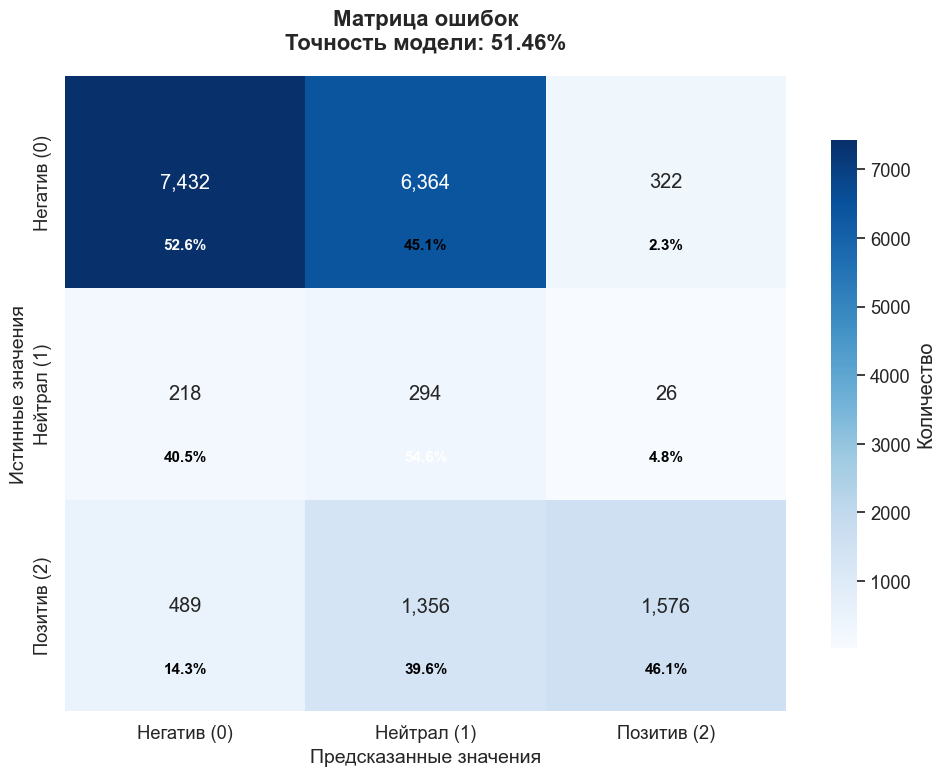

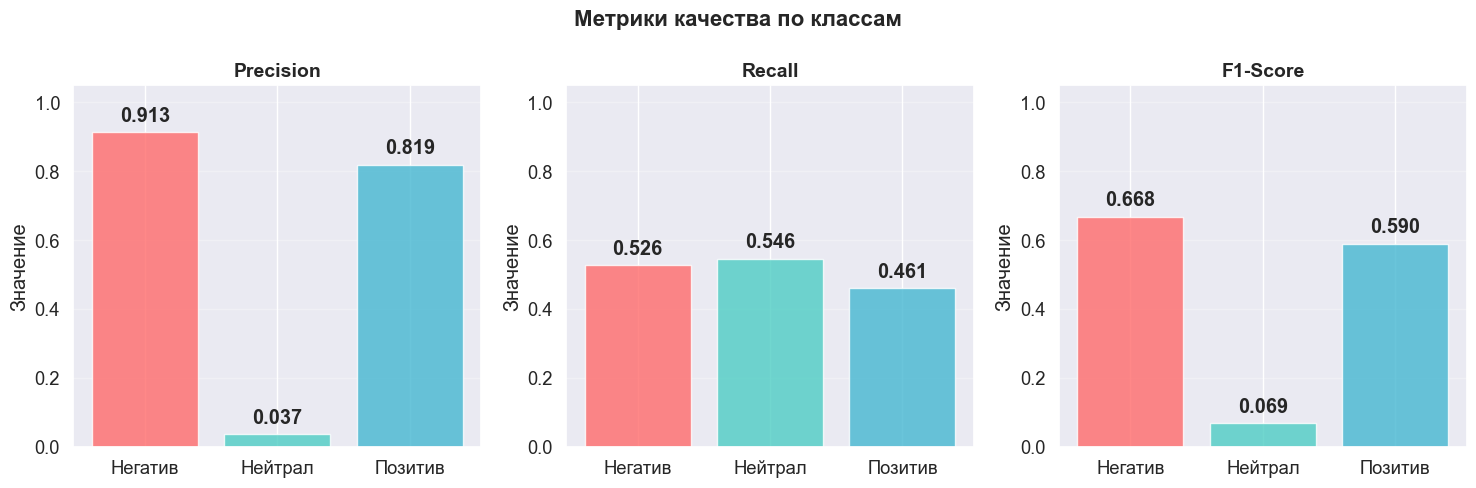


ДЕТАЛЬНЫЙ АНАЛИЗ ОШИБОК

📉 СТАТИСТИКА ОШИБОК:
  Всего ошибок: 8,775
  Общая точность: 51.46%
  Частота ошибок: 48.54%

🔍 ТИПЫ ОШИБОК:
------------------------------------------------------------
Истинный → Предсказанный | Количество | % от ошибок
------------------------------------------------------------
  негатив→нейтрал |      6,364 |  72.52%
  позитив→нейтрал |      1,356 |  15.45%
  позитив→негатив |        489 |   5.57%
  негатив→позитив |        322 |   3.67%
  нейтрал→негатив |        218 |   2.48%
  нейтрал→позитив |         26 |   0.30%

⚠️  ПРОБЛЕМНЫЕ КЛАССЫ:

  НЕГАТИВ (класс 0):
    Ошибок: 6,686 из 14,118 (47.36%)
    Чаще всего путают с нейтрал (6364 раз)

  НЕЙТРАЛ (класс 1):
    Ошибок: 244 из 538 (45.35%)
    Чаще всего путают с негатив (218 раз)

  ПОЗИТИВ (класс 2):
    Ошибок: 1,845 из 3,421 (53.93%)
    Чаще всего путают с нейтрал (1356 раз)

ПРИМЕРЫ ПРЕДСКАЗАНИЙ ДЛЯ ВЕРИФИКАЦИИ ТОЧНОСТИ

Показываю 8 примеров для верификации:

1. ✅ ПРАВИЛЬНО
   Текст: в июне род

In [41]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix, precision_recall_fscore_support
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. НАСТРОЙКА УСТРОЙСТВА И ЗАГРУЗКА МОДЕЛИ
# ============================================================================
print("=" * 70)
print("НАСТРОЙКА СИСТЕМЫ ДЛЯ МАКСИМАЛЬНОЙ ТОЧНОСТИ")
print("=" * 70)

# Проверяем доступность CUDA
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    device = torch.device('cuda:0')
    print(f"Использую GPU: {torch.cuda.get_device_name(0)}")
    print(f"Память GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

    # НЕ используем оптимизации для точности
    torch.backends.cudnn.deterministic = True  # Для воспроизводимости
    torch.backends.cudnn.benchmark = False  # Выключаем для точности
    print("Оптимизации CUDA отключены для максимальной точности")
else:
    device = torch.device('cpu')
    print("Использую CPU")

# ============================================================================
# 2. ЗАГРУЗКА МОДЕЛИ С ПОЛНОЙ ТОЧНОСТЬЮ
# ============================================================================
print("\n" + "=" * 70)
print("ЗАГРУЗКА МОДЕЛИ В РЕЖИМЕ ПОЛНОЙ ТОЧНОСТИ (FP32)")
print("=" * 70)

model_checkpoint = 'cointegrated/rubert-tiny-sentiment-balanced'
print(f"Загружаю модель: {model_checkpoint}")

# Загрузка токенизатора и модели
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint)

# Перенос модели на устройство в режиме полной точности
model.to(device)
model.eval()  # Режим инференса

# Явно указываем тип данных для точности
model.float()  # Убеждаемся, что модель в float32
print(f"Модель загружена в режиме полной точности (FP32)")
print(f"Модель на устройстве: {next(model.parameters()).device}")

# ============================================================================
# 3. ФУНКЦИЯ ДЛЯ ПРЕДСКАЗАНИЙ С МАКСИМАЛЬНОЙ ТОЧНОСТЬЮ
# ============================================================================
def get_sentiment_high_precision(text, return_type='label'):
    """Расчет тональности текста с максимальной точностью"""
    with torch.no_grad():
        # Используем полную длину и точность
        inputs = tokenizer(
            text,
            return_tensors='pt',
            truncation=True,
            padding=True,
            max_length=512  # Полная длина для максимального контекста
        ).to(device)

        # Выполняем вычисления в FP32
        outputs = model(**inputs)
        logits = outputs.logits.float()  # Явно указываем float32
        proba = torch.sigmoid(logits).cpu().numpy()[0]

    if return_type == 'label':
        return model.config.id2label[proba.argmax()]
    elif return_type == 'score':
        return proba.dot([-1, 0, 1])
    return proba

def predict_sentiment_batch_high_precision(texts, batch_size=16):
    """
    Батчевая обработка с максимальной точностью
    Меньший batch_size для избежания усечений
    """
    predictions = []

    print(f"\nОбрабатываю {len(texts):,} текстов с максимальной точностью...")
    print(f"Размер батча: {batch_size} (уменьшен для точности)")
    print(f"Максимальная длина: 512 токенов")

    with tqdm(total=len(texts), desc="Обработка текстов", unit="текст",
              bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]') as pbar:

        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            batch_predictions = []

            # Обрабатываем каждый текст индивидуально для максимальной точности
            for text in batch_texts:
                if isinstance(text, str) and str(text).strip():
                    try:
                        # Индивидуальная обработка каждого текста
                        pred = get_sentiment_high_precision(text, 'label')
                        batch_predictions.append(pred)
                    except Exception as e:
                        print(f"\nОшибка при обработке текста: {str(e)[:100]}...")
                        batch_predictions.append(None)
                else:
                    batch_predictions.append(None)

            predictions.extend(batch_predictions)
            pbar.update(len(batch_texts))

            # Периодический вывод прогресса
            if (i // batch_size) % 100 == 0 and i > 0:
                processed = min(i + batch_size, len(texts))
                print(f"  Обработано: {processed:,} / {len(texts):,}")

    return predictions

# ============================================================================
# 4. ПРИМЕНЕНИЕ МОДЕЛИ К ДАТАФРЕЙМУ
# ============================================================================
print("\n" + "=" * 70)
print("ПРИМЕНЕНИЕ МОДЕЛИ С МАКСИМАЛЬНОЙ ТОЧНОСТЬЮ")
print("=" * 70)

print(f"Размер датафрейма: {len(improved_baseline_dataset):,} записей")

# Получаем предсказания с максимальной точностью
start_time = pd.Timestamp.now()

improved_baseline_dataset['предсказание_модели'] = predict_sentiment_batch_high_precision(
    texts=improved_baseline_dataset['Текст отзыва отчищенный'].tolist(),
    batch_size=8  # Малый батч для точности
)

end_time = pd.Timestamp.now()
processing_time = (end_time - start_time).total_seconds()

print(f"\n✅ Обработка завершена за {processing_time:.1f} секунд")
print(f"Скорость обработки: {len(improved_baseline_dataset)/processing_time:.1f} текстов/сек")

# ============================================================================
# 5. ПРЕОБРАЗОВАНИЕ И ПОДГОТОВКА ДАННЫХ
# ============================================================================
print("\n" + "=" * 70)
print("ПРЕОБРАЗОВАНИЕ МЕТОК И ПОДГОТОВКА ДАННЫХ")
print("=" * 70)

# Маппинг меток модели к числовым значениям
label_mapping = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

numeric_labels = {
    0: 'негатив',
    1: 'нейтрал',
    2: 'позитив'
}

# Создаем числовые версии предсказаний
improved_baseline_dataset['предсказание_числовое'] = improved_baseline_dataset['предсказание_модели'].map(label_mapping)

# Проверяем качество предсказаний
null_count = improved_baseline_dataset['предсказание_модели'].isnull().sum()
print(f"Пропущенных предсказаний: {null_count} ({null_count/len(improved_baseline_dataset)*100:.2f}%)")

# Распределение предсказаний
print("\nРаспределение предсказаний модели:")
pred_distribution = improved_baseline_dataset['предсказание_модели'].value_counts()
for label, count in pred_distribution.items():
    if pd.notna(label):
        percentage = count / len(improved_baseline_dataset) * 100
        print(f"  {label}: {count:,} ({percentage:.1f}%)")

# Подготовка данных для оценки
df_eval = improved_baseline_dataset.dropna(subset=['тональность', 'предсказание_числовое']).copy()
df_eval['тональность'] = df_eval['тональность'].astype(int)
df_eval['предсказание_числовое'] = df_eval['предсказание_числовое'].astype(int)

print(f"\n📊 Статистика датасета для оценки:")
print(f"  Всего записей: {len(improved_baseline_dataset):,}")
print(f"  Для оценки: {len(df_eval):,}")
print(f"  Отфильтровано: {len(improved_baseline_dataset) - len(df_eval):,}")

# ============================================================================
# 6. ВЫЧИСЛЕНИЕ МЕТРИК КАЧЕСТВА
# ============================================================================
print("\n" + "=" * 70)
print("ВЫЧИСЛЕНИЕ МЕТРИК КАЧЕСТВА")
print("=" * 70)

# Подготовка данных
y_true = df_eval['тональность'].values
y_pred = df_eval['предсказание_числовое'].values

# Распределение меток
print("\n📈 РАСПРЕДЕЛЕНИЕ МЕТОК:")
print("-" * 50)

true_counts = np.bincount(y_true, minlength=3)
pred_counts = np.bincount(y_pred, minlength=3)

print("Истинные метки:")
for i in range(3):
    pct = true_counts[i] / len(y_true) * 100
    print(f"  {numeric_labels[i]} ({i}): {true_counts[i]:,} ({pct:.1f}%)")

print("\nПредсказанные метки:")
for i in range(3):
    pct = pred_counts[i] / len(y_pred) * 100
    print(f"  {numeric_labels[i]} ({i}): {pred_counts[i]:,} ({pct:.1f}%)")

# Вычисление основных метрик
print("\n🎯 ОСНОВНЫЕ МЕТРИКИ:")
print("-" * 50)

accuracy = accuracy_score(y_true, y_pred)
f1_weighted = f1_score(y_true, y_pred, average='weighted')
f1_macro = f1_score(y_true, y_pred, average='macro')
precision_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Accuracy:           {accuracy:.4f}")
print(f"F1-weighted:        {f1_weighted:.4f}")
print(f"F1-macro:           {f1_macro:.4f}")
print(f"Precision-weighted: {precision_weighted:.4f}")
print(f"Recall-weighted:    {recall_weighted:.4f}")

# Детальный отчет по классам
print("\n📊 ДЕТАЛЬНЫЙ ОТЧЕТ ПО КЛАССАМ:")
print("-" * 50)

target_names = ['Негатив (0)', 'Нейтрал (1)', 'Позитив (2)']
report = classification_report(y_true, y_pred, target_names=target_names, digits=4)
print(report)

# Метрики по каждому классу
print("\n🎯 МЕТРИКИ ПО КЛАССАМ:")
print("-" * 50)

precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
    y_true, y_pred, labels=[0, 1, 2]
)

for i, label_name in enumerate(['Негатив', 'Нейтрал', 'Позитив']):
    print(f"\n{label_name} (класс {i}):")
    print(f"  Образцов:    {support_per_class[i]:,}")
    print(f"  Precision:   {precision_per_class[i]:.4f}")
    print(f"  Recall:      {recall_per_class[i]:.4f}")
    print(f"  F1-score:    {f1_per_class[i]:.4f}")

# ============================================================================
# 7. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ============================================================================
print("\n" + "=" * 70)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("=" * 70)

# Матрица ошибок
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.set(font_scale=1.2)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names,
            cbar_kws={'label': 'Количество', 'shrink': 0.8})

plt.title(f'Матрица ошибок\nТочность модели: {accuracy:.2%}',
          fontsize=16, pad=20, fontweight='bold')
plt.ylabel('Истинные значения', fontsize=14)
plt.xlabel('Предсказанные значения', fontsize=14)
plt.tight_layout()

# Добавляем проценты
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
for i in range(3):
    for j in range(3):
        if cm[i, j] > 0:
            plt.text(j + 0.5, i + 0.8, f"{cm_normalized[i, j]:.1f}%",
                    ha='center', va='center',
                    color='white' if cm_normalized[i, j] > 50 else 'black',
                    fontsize=11, fontweight='bold')

plt.savefig('confusion_matrix_full_precision.png', dpi=150, bbox_inches='tight')
plt.show()

# График метрик по классам
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_data = [
    ('Precision', precision_per_class),
    ('Recall', recall_per_class),
    ('F1-Score', f1_per_class)
]

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for idx, (ax, (metric_name, data)) in enumerate(zip(axes, metrics_data)):
    bars = ax.bar(range(3), data, color=colors, alpha=0.8)
    ax.set_title(metric_name, fontsize=14, fontweight='bold')
    ax.set_xticks(range(3))
    ax.set_xticklabels(['Негатив', 'Нейтрал', 'Позитив'])
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylabel('Значение')

    for bar, value in zip(bars, data):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Метрики качества по классам', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('class_metrics_full_precision.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 8. АНАЛИЗ ОШИБОК
# ============================================================================
print("\n" + "=" * 70)
print("ДЕТАЛЬНЫЙ АНАЛИЗ ОШИБОК")
print("=" * 70)

# Статистика ошибок
errors = y_true != y_pred
error_count = errors.sum()
error_rate = error_count / len(y_true)

print(f"\n📉 СТАТИСТИКА ОШИБОК:")
print(f"  Всего ошибок: {error_count:,}")
print(f"  Общая точность: {accuracy:.2%}")
print(f"  Частота ошибок: {error_rate:.2%}")

# Матрица ошибок (только ошибочные предсказания)
error_matrix = np.zeros((3, 3), dtype=int)
for true, pred in zip(y_true, y_pred):
    if true != pred:
        error_matrix[true, pred] += 1

print("\n🔍 ТИПЫ ОШИБОК:")
print("-" * 60)
print("Истинный → Предсказанный | Количество | % от ошибок")
print("-" * 60)

total_errors = error_matrix.sum()
error_types = []

for i in range(3):
    for j in range(3):
        if i != j and error_matrix[i, j] > 0:
            error_count_ij = error_matrix[i, j]
            error_pct = error_count_ij / total_errors * 100
            error_types.append((f"{numeric_labels[i]}→{numeric_labels[j]}", error_count_ij, error_pct))

# Сортируем по количеству ошибок
error_types.sort(key=lambda x: x[1], reverse=True)

for error_name, count, pct in error_types:
    print(f"  {error_name:15} | {count:10,} | {pct:6.2f}%")

# Анализ проблемных классов
print("\n⚠️  ПРОБЛЕМНЫЕ КЛАССЫ:")
for i in range(3):
    class_errors = error_matrix[i].sum()
    class_total = true_counts[i]
    if class_total > 0:
        class_error_rate = class_errors / class_total

        if class_errors > 0:
            worst_mistake = np.argmax(error_matrix[i])
            worst_count = error_matrix[i].max()

            print(f"\n  {numeric_labels[i].upper()} (класс {i}):")
            print(f"    Ошибок: {class_errors:,} из {class_total:,} ({class_error_rate:.2%})")
            print(f"    Чаще всего путают с {numeric_labels[worst_mistake]} ({worst_count} раз)")

# ============================================================================
# 9. ПРИМЕРЫ ПРЕДСКАЗАНИЙ ДЛЯ ВЕРИФИКАЦИИ
# ============================================================================
print("\n" + "=" * 70)
print("ПРИМЕРЫ ПРЕДСКАЗАНИЙ ДЛЯ ВЕРИФИКАЦИИ ТОЧНОСТИ")
print("=" * 70)

# Выбираем разнообразные примеры
np.random.seed(42)
n_examples = 8
correct_indices = np.where(y_true == y_pred)[0]
error_indices = np.where(y_true != y_pred)[0]

if len(correct_indices) > 0 and len(error_indices) > 0:
    correct_samples = np.random.choice(correct_indices, min(4, len(correct_indices)), replace=False)
    error_samples = np.random.choice(error_indices, min(4, len(error_indices)), replace=False)
    sample_indices = np.concatenate([correct_samples, error_samples])
else:
    sample_indices = np.random.choice(len(df_eval), min(n_examples, len(df_eval)), replace=False)

print(f"\nПоказываю {len(sample_indices)} примеров для верификации:")
print("=" * 80)

for idx, sample_idx in enumerate(sample_indices, 1):
    row = df_eval.iloc[sample_idx]
    text = row['Текст отзыва отчищенный']

    # Форматируем текст для вывода
    if len(text) > 120:
        text_preview = text[:120] + '...'
    else:
        text_preview = text

    true_label = int(row['тональность'])
    pred_label = int(row['предсказание_числовое'])
    pred_text = row['предсказание_модели']

    is_correct = true_label == pred_label
    status = "✅ ПРАВИЛЬНО" if is_correct else "❌ ОШИБКА"

    print(f"\n{idx}. {status}")
    print(f"   Текст: {text_preview}")
    print(f"   Истинная тональность: {true_label} ({numeric_labels[true_label]})")
    print(f"   Предсказание модели: {pred_label} ({pred_text})")

    if not is_correct:
        print(f"   Тип ошибки: {numeric_labels[true_label]} → {pred_text}")

# ============================================================================
# 10. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# ============================================================================
print("\n" + "=" * 70)
print("СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
print("=" * 70)

# Добавляем колонку с результатом сравнения
improved_baseline_dataset['предсказание_верно'] = improved_baseline_dataset.apply(
    lambda row: 1 if (pd.notna(row['тональность']) and
                     pd.notna(row['предсказание_числовое']) and
                     int(row['тональность']) == row['предсказание_числовое'])
                else 0 if (pd.notna(row['тональность']) and
                          pd.notna(row['предсказание_числовое']))
                else np.nan,
    axis=1
)

# Сохраняем полный датафрейм
output_file_csv = 'improved_baseline_dataset_predictions_full_precision.csv'
print(f"\n💾 Сохраняю датафрейм в {output_file_csv}...")
improved_baseline_dataset.to_csv(output_file_csv, index=False, encoding='utf-8-sig')
print(f"✅ Датафрейм сохранен: {output_file_csv}")
print(f"   Размер: {len(improved_baseline_dataset):,} записей")

# Сохраняем сводный отчет
summary_file = 'model_evaluation_full_precision.txt'
print(f"\n📄 Создаю сводный отчет: {summary_file}")

with open(summary_file, 'w', encoding='utf-8') as f:
    f.write("=" * 80 + "\n")
    f.write("СВОДНЫЙ ОТЧЕТ ОЦЕНКИ МОДЕЛИ SENTIMENT ANALYSIS (МАКСИМАЛЬНАЯ ТОЧНОСТЬ)\n")
    f.write("=" * 80 + "\n\n")

    f.write(f"Модель: {model_checkpoint}\n")
    f.write(f"Дата оценки: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Режим: Полная точность (FP32), без оптимизаций\n")
    f.write(f"Устройство: {device}\n")
    f.write(f"Время обработки: {processing_time:.1f} секунд\n\n")

    f.write("СТАТИСТИКА ДАТАСЕТА:\n")
    f.write("-" * 50 + "\n")
    f.write(f"Всего записей: {len(improved_baseline_dataset):,}\n")
    f.write(f"Для оценки: {len(df_eval):,}\n")
    f.write(f"Отфильтровано: {len(improved_baseline_dataset) - len(df_eval):,}\n\n")

    f.write("МЕТРИКИ КАЧЕСТВА:\n")
    f.write("-" * 50 + "\n")
    f.write(f"Accuracy:           {accuracy:.4f}\n")
    f.write(f"F1-weighted:        {f1_weighted:.4f}\n")
    f.write(f"F1-macro:           {f1_macro:.4f}\n")
    f.write(f"Precision-weighted: {precision_weighted:.4f}\n")
    f.write(f"Recall-weighted:    {recall_weighted:.4f}\n\n")

    f.write("РАСПРЕДЕЛЕНИЕ МЕТОК:\n")
    f.write("-" * 50 + "\n")
    f.write("Истинные метки:\n")
    for i in range(3):
        pct = true_counts[i] / len(y_true) * 100
        f.write(f"  {numeric_labels[i]}: {true_counts[i]:,} ({pct:.1f}%)\n")

    f.write("\nПредсказанные метки:\n")
    for i in range(3):
        pct = pred_counts[i] / len(y_pred) * 100
        f.write(f"  {numeric_labels[i]}: {pred_counts[i]:,} ({pct:.1f}%)\n\n")

    f.write("МЕТРИКИ ПО КЛАССАМ:\n")
    f.write("-" * 50 + "\n")
    for i in range(3):
        f.write(f"\n{numeric_labels[i].upper()} (класс {i}):\n")
        f.write(f"  Precision:   {precision_per_class[i]:.4f}\n")
        f.write(f"  Recall:      {recall_per_class[i]:.4f}\n")
        f.write(f"  F1-score:    {f1_per_class[i]:.4f}\n")
        f.write(f"  Поддержка:   {support_per_class[i]:,}\n")

    f.write(f"\n\nОШИБКИ:\n")
    f.write("-" * 50 + "\n")
    f.write(f"Всего ошибок: {error_count:,}\n")
    f.write(f"Частота ошибок: {error_rate:.2%}\n\n")

    if error_types:
        f.write("ТИПЫ ОШИБОК (от наиболее частых):\n")
        for error_name, count, pct in error_types:
            f.write(f"  {error_name}: {count:,} ({pct:.1f}%)\n")

print(f"✅ Отчет сохранен: {summary_file}")

# ============================================================================
# 11. ФИНАЛЬНАЯ СТАТИСТИКА
# ============================================================================
print("\n" + "=" * 70)
print("ФИНАЛЬНАЯ СТАТИСТИКА")
print("=" * 70)

# Финальная статистика
correct_total = improved_baseline_dataset['предсказание_верно'].sum()
total_evaluated = improved_baseline_dataset['предсказание_верно'].notna().sum()
final_accuracy = correct_total / total_evaluated if total_evaluated > 0 else 0

print(f"\n📊 ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ:")
print(f"  Всего записей:           {len(improved_baseline_dataset):,}")
print(f"  Успешно оценено:         {total_evaluated:,}")
print(f"  Правильных предсказаний: {correct_total:,}")
print(f"  Точность модели:         {final_accuracy:.2%}")
print(f"  Ошибок:                  {total_evaluated - correct_total:,}")

print(f"\n⏱️  ПРОИЗВОДИТЕЛЬНОСТЬ:")
print(f"  Время обработки:         {processing_time:.1f} секунд")
print(f"  Скорость обработки:      {len(improved_baseline_dataset)/processing_time:.1f} текстов/сек")
print(f"  Среднее время на текст:  {processing_time/len(improved_baseline_dataset)*1000:.1f} мс")

print("\n" + "=" * 70)
print("✅ ОБРАБОТКА ЗАВЕРШЕНА В РЕЖИМЕ МАКСИМАЛЬНОЙ ТОЧНОСТИ")
print("=" * 70)
print(f"\n📁 Результаты сохранены в файлах:")
print(f"   1. {output_file_csv} - данные с предсказаниями")
print(f"   2. {summary_file} - сводный отчет")
print(f"   3. confusion_matrix_full_precision.png - матрица ошибок")
print(f"   4. class_metrics_full_precision.png - метрики по классам")